# **Clustering**

## **Постановка задачи**
Для изучения алгоритмов кластеризации будем использовать следующую спецификацию на данных RLMS. Будем считать, что заработная плата для любого индивида определяется следующими факторами: пол (дамми), стаж, количество лет образования, возраст, тип населенного пункта (дамми), является государство владельцем или совладельцем вашего предприятия (дамми). Все остальные имеющиеся в датасете RLMS переменные (отрасль, профессиональная группа, средняя продолжительность рабочей недели, количество подчиненных, сколько человек работает на вашем предприятии) будем использовать для разбиения респодентов на группы, внутри которых, предположительно, степень влияние выбранных факторов на зарплату будет схожей, а между - различной. Например, можно предположить, что в разных отраслях образование имеет разную степень влияния на зарплату (медицина vs торговля).

Т.к методы кластерного анализа основаны на расчете расстояния, для дальнейшего рассмотрения

- оставим количественные переменные:
  - средняя продолжительность рабочей недели,
  - количество подчиненных,
  - сколько человек работает на вашем предприятии;
- преобразуем категориальные переменные:
  - из категориальной отрасли сделаем три количественные переменные - каждому респонденту присвоим 1. долю работников с высшим образованием по данным Росстата за 2024 по отрасли респондента 2. долю работников со средним образованием по данным Росстата за 2024 по отрасли респондента и 3. производительность труда в отрасли респондента за 2023 (т.к. более свежих данных нет).
  - из профессиональной группы сделаем переменную, соответствующую уровню безработицы по профессиональной группе респондента по данным Росстата (как отражение спроса на отдельные категории работников).


## **О процедурах кластеризации**

  Главная цель кластерного анализа-нахождение схожих объектов в выборке данных. Для проведения кластерного анализа в python есть возможность использовать иерархические кластер-процедуры, метода k-средних, DBSCAN и HDBSCAN.
  
  Принцип работы агломеративных иерархических процедур  состоит в последовательном объединении  групп элементов, сначала самых близких, а затем — все более отдаленных  друг от друга. На первом шаге объекты рассматриваются как самостоятельные кластеры. На последнем шаге все события объединяются в одну большую группу. По определению в результате работы этих кластерных методов получаются неперекрывающиеся кластеры, которые, однако, являются вложенными в том смысле, что каждый кластер может рассматриваться как элемент другого, более широкого кластера на более высоком уровне сходства.

  При наличии большого количества наблюдений применяют метод к-средних. Особенность этого метода заключается в том, что здесь необходимо заранее задавать количество кластеров, а не так как в иерархическом анализе, получить в качестве результата. Метод k-средних-итеративный метод группировки, который  работает следующим образом:
1.	Разбивают данные на некоторое заданное число кластеров; вычисляют центры тяжести этих кластеров.
2.	Помещают каждую точку в кластер с ближайшим центром тяжести.
3.	Вычисляют новые центры тяжести кластеров; кластеры не заменяются на новые до тех пор, пока не будут просмотрены полностью все данные.
4.	Шаги 2 и 3 повторяются до тех пор, пока не перестанут меняться кластеры.

Подробнее о методах кластеризации, включая DBSCAN и HDBSCAN [здесь](https://github.com/evgpat/ml_basics_course/blob/main/lesson_11/11.%20Лекция.%20Кластеризация.pdf) и [здесь](https://scikit-learn.ru/stable/modules/clustering.html#hdbscan).

In [ ]:
# Ипортируем библиотеки
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, homogeneity_score, v_measure_score

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Изменим значение максимального количества отображаемых строк и столбцов
pd.options.display.max_columns = 50
pd.options.display.max_rows = 100
# Поменяем формат вывода чисел: разделим разряды запятой и будем выводить два знака после точки
pd.options.display.float_format = '{:,.2f}'.format

In [ ]:
# Зададим параметры, которые будут использоваться в расчетах ниже.
random_state=12345

# Для расшифровки полей датасета исп. https://www.hse.ru/rlms/code ф. "Описание переменных файла данных по индивидам" для Волна 33 (2024 г.)
# Список используемых колонок
features = ['ccid_i', 'ccj6_2', 'cc_occup08', 'ccj4_1', 'ccj6', 'ccj6_0', 'ccj13', 'ccm20_7', 'ccj77', 'ccj90', 'ccs7', 'ccj10']

# Словарь для кодирования ccj4_1 (отрасль) через долю занятых с высшим образованием по отраслям https://rosstat.gov.ru/storage/mediabank/Trud_2025.html (раздел 1, таблица 1.48-1.49)
higher_ed_by_ccj4_1 = {
    1: 28.8,   # Лёгкая, пищевая промышленность → Обрабатывающие производства
    2: 28.8,   # Гражданское машиностроение → Обрабатывающие производства
    3: 28.8,   # Военно-промышленный комплекс → Обрабатывающие производства
    4: 30.1,   # Нефтегазовая промышленность → Добыча полезных ископаемых
    5: 28.8,   # Другая отрасль тяжёлой промышленности → Обрабатывающие производства
    6: 29.3,   # Строительство → Строительство
    7: 21.3,   # Транспорт, связь → Транспортировка и хранение
    8: 15.3,   # Сельское хозяйство → Сельское, лесное хозяйство, охота, рыболовство
    9: 57.8,   # Органы управления → Государственное управление
    10: 57.2,  # Образование → Образование
    11: 56.3,  # Наука, культура → среднее между (наука) и (культура)
    12: 40.0,  # Здравоохранение → Здравоохранение и социальные услуги
    13: 57.8,  # Армия, МВД → Государственное управление и военная безопасность
    14: 24.6,  # Торговля, бытовое обслуживание → Торговля
    15: 70.3,  # Финансы → Финансовая и страховая деятельность
    16: 34.1,  # Энергетическая промышленность → Обеспечение электрической энергией, газом и паром
    17: 23.9,  # ЖКХ → Водоснабжение; водоотведение, утилизация отходов
    18: 35.1,  # Операции с недвижимостью → Операции с недвижимым имуществом
    20: 40.0,  # Социальное обслуживание → Здравоохранение и социальные услуги
    21: 60.4,  # Юриспруденция → Профессиональная, научная и техническая деятельность
    22: 22.6,  # Церковь → Предоставление прочих видов услуг
    23: 28.8,  # Химическая промышленность → Обрабатывающие производства
    24: 22.0,  # Деревообработка, лесное хозяйство → среднее между (сельское/лесное) и (обрабатывающие)
    25: 52.3,  # Спорт, туризм, развлечения → Культура, спорт, досуг
    26: 22.6,  # Услуги населению → Предоставление прочих видов услуг
    27: 71.3,  # ИКТ → Деятельность в области информации и связи
    28: 23.9,  # Экология, защита окружающей среды → Водоснабжение; утилизация отходов
    29: 18.9,  # Общественное питание → Гостиницы и общественное питание
    30: 71.3,  # СМИ, издательство, телекоммуникации → Информация и связь
    31: 60.4,  # Реклама, маркетинг → Профессиональная, научная и техническая деятельность
    32: 22.6   # Общественные организации → Предоставление прочих видов услуг
    }

# Словарь для кодирования ccj4_1 (отрасль) через долю занятых со средним образованием по отраслям https://rosstat.gov.ru/storage/mediabank/Trud_2025.html (раздел 1, таблица 1.48-1.49)
secondary_ed_by_ccj4_1 = {
    1: 53.5,   # Лёгкая, пищевая промышленность → Обрабатывающие производства
    2: 53.5,   # Гражданское машиностроение → Обрабатывающие производства
    3: 53.5,   # Военно-промышленный комплекс → Обрабатывающие производства
    4: 53.0,   # Нефтегазовая промышленность → Добыча полезных ископаемых
    5: 53.5,   # Другая отрасль тяжёлой промышленности → Обрабатывающие производства
    6: 49.2,   # Строительство → Строительство
    7: 53.6,   # Транспорт, связь → Транспортировка и хранение
    8: 44.4,   # Сельское хозяйство → Сельское, лесное хозяйство, охота, рыболовство
    9: 31.3,   # Органы управления → Государственное управление
    10: 33.5,  # Образование → Образование
    11: 33.5,  # Наука, культура → среднее между (наука) и (культура)
    12: 51.1,  # Здравоохранение → Здравоохранение и социальные услуги
    13: 31.3,  # Армия, МВД → Государственное управление и военная безопасность
    14: 50.4,  # Торговля, бытовое обслуживание → Торговля
    15: 26.6,  # Финансы → Финансовая и страховая деятельность
    16: 54.3,  # Энергетическая промышленность → Обеспечение электрической энергией, газом и паром
    17: 52.8,  # ЖКХ → Водоснабжение; водоотведение, утилизация отходов
    18: 47.0,  # Операции с недвижимостью → Операции с недвижимым имуществом
    20: 51.1,  # Социальное обслуживание → Здравоохранение и социальные услуги
    21: 29.7,  # Юриспруденция → Профессиональная, научная и техническая деятельность
    22: 59.6,  # Церковь → Предоставление прочих видов услуг
    23: 53.5,  # Химическая промышленность → Обрабатывающие производства
    24: 49.0,  # Деревообработка, лесное хозяйство → среднее между (сельское/лесное) и (обрабатывающие)
    25: 37.3,  # Спорт, туризм, развлечения → Культура, спорт, досуг
    26: 59.6,  # Услуги населению → Предоставление прочих видов услуг
    27: 23.7,  # ИКТ → Деятельность в области информации и связи
    28: 52.8,  # Экология, защита окружающей среды → Водоснабжение; утилизация отходов
    29: 57.2,  # Общественное питание → Гостиницы и общественное питание
    30: 23.7,  # СМИ, издательство, телекоммуникации → Информация и связь
    31: 29.7,  # Реклама, маркетинг → Профессиональная, научная и техническая деятельность
    32: 59.6   # Общественные организации → Предоставление прочих видов услуг
}

# Словарь для кодирования ccj4_1 (отрасль) через производительность труда = Валовая добавленная стоимость по отраслям экономики в расчете на 1 занятого за 2023 в тек.ценах в тыс руб https://rosstat.gov.ru/statistics/accounts / Среднегодовая численность занятых в 2023 https://www.fedstat.ru/indicator/58994 /12
productivity_by_ccj4_1 = {
    1: 2189,     # Лёгкая, пищевая промышленность → Обрабатывающие производства
    2: 2189,     # Гражданское машиностроение → Обрабатывающие производства
    3: 2189,     # Военно-промышленный комплекс → Обрабатывающие производства
    4: 15361,    # Нефтегазовая промышленность → Добыча полезных ископаемых
    5: 2189,     # Другая отрасль тяжёлой промышленности → Обрабатывающие производства
    6: 1188,     # Строительство → Строительство
    7: 1839,     # Транспорт, связь → Транспортировка и хранение
    8: 1194,     # Сельское хозяйство → Сельское, лесное хозяйство, охота, рыболовство
    9: 3670,     # Органы управления → Государственное управление
    10: 852,     # Образование → Образование
    11: 2020,    # Наука, культура → среднее между (наука) и (культура)
    12: 1101,    # Здравоохранение → Здравоохранение и социальные услуги
    13: 3670,    # Армия, МВД → Государственное управление и военная безопасность
    14: 1502,    # Торговля, бытовое обслуживание → Торговля
    15: 6263,    # Финансы → Финансовая и страховая деятельность
    16: 2228,    # Энергетическая промышленность → Обеспечение электрической энергией, газом и паром
    17: 1180,    # ЖКХ → Водоснабжение; водоотведение, утилизация отходов
    18: 9173,    # Операции с недвижимостью → Операции с недвижимым имуществом
    20: 1101,    # Социальное обслуживание → Здравоохранение и социальные услуги
    21: 2585,    # Юриспруденция → Профессиональная, научная и техническая деятельность
    22: 435,     # Церковь → Предоставление прочих видов услуг
    23: 2189,    # Химическая промышленность → Обрабатывающие производства
    24: 1692,    # Деревообработка, лесное хозяйство → среднее между 1194 (сельское/лесное) и 2189 (обрабатывающие)
    25: 1455,    # Спорт, туризм, развлечения → Культура, спорт, досуг
    26: 435,     # Услуги населению → Предоставление прочих видов услуг
    27: 3011,    # ИКТ → Деятельность в области информации и связи
    28: 1180,    # Экология, защита окружающей среды → Водоснабжение; утилизация отходов
    29: 734,     # Общественное питание → Гостиницы и общественное питание
    30: 3011,    # СМИ, издательство, телекоммуникации → Информация и связь
    31: 2585,    # Реклама, маркетинг → Профессиональная, научная и техническая деятельность
    32: 435      # Общественные организации → Предоставление прочих видов услуг
}

industry_labels = {
    1: 'Лёгкая, пищевая промышленность → Обрабатывающие производства (ОКВЭД)',
    2: 'Гражданское машиностроение → Обрабатывающие производства (ОКВЭД)',
    3: 'ВПК → Обрабатывающие производства (ОКВЭД)',
    4: 'Нефтегазовая промышленность → Добыча полезных ископаемых (ОКВЭД)',
    5: 'Другая тяжёлая промышленность  → Обрабатывающие производства (ОКВЭД)',
    6: 'Строительство → Строительство (ОКВЭД)',
    7: 'Транспорт, связь → Транспортировка и хранение (ОКВЭД)',
    8: 'Сельское хозяйство → Сельское, лесное хозяйство, охота, рыболовство  (ОКВЭД)',
    9: 'Органы управления → Государственное управление  (ОКВЭД)',
    10: 'Образование → Образование  (ОКВЭД)',
    11: 'Наука, культура → среднее между (наука) и (культура)  (ОКВЭД)',
    12: 'Здравоохранение → Здравоохранение и социальные услуги',
    13: 'Армия, МВД → Государственное управление и военная безопасность (ОКВЭД)',
    14: 'Торговля, бытовое обслуживание → Торговля (ОКВЭД)',
    15: 'Финансы → Финансовая и страховая деятельность (ОКВЭД)',
    16: 'Энергетика → Обеспечение электрической энергией, газом и паром (ОКВЭД)',
    17: 'ЖКХ → Водоснабжение; водоотведение, утилизация отходов (ОКВЭД)',
    18: 'Недвижимость → Операции с недвижимым имуществом (ОКВЭД)',
    20: 'Социальное обслуживание → Здравоохранение и социальные услуги (ОКВЭД)',
    21: 'Юриспруденция → Профессиональная, научная и техническая деятельность (ОКВЭД)',
    22: 'Церковь → Предоставление прочих видов услуг (ОКВЭД)',
    23: 'Химическая промышленность → Обрабатывающие производства (ОКВЭД)',
    24: 'Деревообработка, лесное хозяйство → среднее между (сельское/лесное) и (обрабатывающие) (ОКВЭД)',
    25: 'Спорт, туризм, развлечения → Культура, спорт, досуг (ОКВЭД)',
    26: 'Услуги населению → Предоставление прочих видов услуг (ОКВЭД)',
    27: 'ИКТ → Деятельность в области информации и связи (ОКВЭД)',
    28: 'Экология → Водоснабжение; утилизация отходов (ОКВЭД)',
    29: 'Общественное питание → Гостиницы и общественное питание (ОКВЭД)',
    30: 'СМИ, телекоммуникации → Информация и связь (ОКВЭД)',
    31: 'Реклама, маркетинг → Профессиональная, научная и техническая деятельность (ОКВЭД)',
    32: 'Общественные организации → Предоставление прочих видов услуг (ОКВЭД)'
}

# Словарь для кодирования cc_occup08 (профессиональная группа) по данным Росстата https://rosstat.gov.ru/storage/mediabank/Trud_2025.html (раздел 1, таблица 1.80)
indicator_by_cc_occup08 = {
    0: None,        # военнослужащие (нет данных)
    1: 0.9,         # Руководители
    2: 1.0,         # Специалисты высшего уровня квалификации
    3: 1.2,         # Специалисты среднего уровня квалификации
    4: 2.1,         # Служащие, занятые подготовкой и оформлением документации, учетом и обслуживанием
    5: 2.8,         # Работники сферы обслуживания и торговли, охраны граждан и собственности
    6: 1.9,         # Квалифицированные работники сельского и лесного хозяйства, рыбоводства и рыболовства
    7: 1.9,         # Квалифицированные рабочие промышленности, строительства, транспорта и рабочие родственных занятий
    8: 1.9,         # Операторы производственных установок и машин, сборщики и водители
    9: 4.4,         # Неквалифицированные рабочие
}

## **Сбор данных**

In [ ]:
%%time
# Загрузим датасет с GitHub
url = "https://raw.githubusercontent.com/eilicheva-art/datasets/refs/heads/main/ind_rlms_2024.csv"
df = pd.read_csv(url, on_bad_lines='skip', sep=';')
# Оставим только нужные колонки
df = df[features]
# Выведим первые 5 строк датафрейма
df.head()

CPU times: user 1.6 s, sys: 212 ms, total: 1.81 s
Wall time: 2.5 s


,ccid_i,ccj6_2,cc_occup08,ccj4_1,ccj6,ccj6_0,ccj13,ccm20_7,ccj77,ccj90,ccs7,ccj10
0,"1,008,401.00",NaN,NaN,NaN,NaN,NaN,NaN,2.00,2.00,4.00,1.00,NaN
1,"1,008,801.00",NaN,NaN,NaN,NaN,NaN,NaN,1.00,2.00,4.00,1.00,NaN
2,"1,008,901.00",NaN,NaN,NaN,NaN,NaN,NaN,1.00,2.00,4.00,1.00,NaN
3,"1,010,801.00","99,999,997.00",5.00,2.00,2.00,NaN,150.00,2.00,1.00,12.00,1.00,"22,000.00"
4,"1,010,802.00",45.00,5.00,2.00,2.00,NaN,"99,999,997.00",2.00,1.00,12.00,1.00,"50,000.00"


In [ ]:
# Выведим общую информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ccid_i      12000 non-null  float64
 1   ccj6_2      5387 non-null   float64
 2   cc_occup08  5387 non-null   float64
 3   ccj4_1      5387 non-null   float64
 4   ccj6        5387 non-null   float64
 5   ccj6_0      888 non-null    float64
 6   ccj13       4758 non-null   float64
 7   ccm20_7     12000 non-null  float64
 8   ccj77       10303 non-null  float64
 9   ccj90       10303 non-null  float64
 10  ccs7        10303 non-null  float64
 11  ccj10       5245 non-null   float64
dtypes: float64(12)
memory usage: 1.1 MB


Итак, для кластеризации собрали 12 колонок, из них

 - фичи (5 шт.):  `cc_occup08` - профессиональная группа; `ccj4_1` - в какой отрасли вы работаете на этой работе?; `ccj6_0` - количество подчиненных;  `ccj6_2` - продолжительность рабочей недели в часах; `ccj13` - сколько человек работает на вашем предприятии? если не знаете точно, скажите примерно.

 - переменные для фильтрации (4 шт.): `ccm20_7` - какая группа инвалидности вам назначена?; `ccj77` - есть ли работа у респондента?; `ccj90` - какой ответ лучше всего описывает ваше основное занятие в настоящее время?; `ccs7` - отметьте, насколько по-вашему мнению надежна получаемая информация.

In [ ]:
# Проведем предварительную фильтрацию датафрейма
df = df[df['ccm20_7']==2] # отфильтруем неинвалидов
df = df[df['ccj77']==1] # отфильтруем только имеющих работу
df = df[(df['ccj90']>=10)&(df['ccj90']<=13)] # отфильтруем только работающих, предпринемателей, фермеров (исключим учеников, пенсионеров, студентов, ...)
df = df[df['ccs7']==1] # отфильтруем только надежную информацию
# Удалим далее неинформативные столбцы
del df['ccm20_7']
del df['ccj77']
del df['ccj90']
del df['ccs7']
# Выведим первые 5 строк датафрейма
df.head()

,ccid_i,ccj6_2,cc_occup08,ccj4_1,ccj6,ccj6_0,ccj13,ccj10
3,"1,010,801.00","99,999,997.00",5.00,2.00,2.00,NaN,150.00,"22,000.00"
4,"1,010,802.00",45.00,5.00,2.00,2.00,NaN,"99,999,997.00","50,000.00"
5,"1,010,803.00","99,999,997.00",7.00,"99,999,999.00",2.00,NaN,"99,999,997.00",NaN
9,"9,000,503.00",40.00,3.00,11.00,2.00,NaN,20.00,"45,000.00"
12,"9,005,501.00",40.00,5.00,14.00,2.00,NaN,NaN,"60,000.00"


In [ ]:
# Выведим количество строк датафрейма после фильтрации
print("Количество строк:", df.shape[0])
# Выведим количество уникальных id респондентов
print("Количество уникальных респондентов:", len(df['ccid_i'].unique()))

Количество строк: 5047
Количество уникальных респондентов: 5047


## **Предобработка данных**

#### **Изучение и предобработка фичей**

##### **ccj10 (зарплата за последние 30 дней по основной работе)**

In [ ]:
# Заполним пропуски
df.loc[df['ccj10'].isnull()==True, 'ccj10'] = 'unknown'
df.loc[df['ccj10'] == 99999997, 'ccj10'] = 'unknown'
df.loc[df['ccj10'] == 99999998, 'ccj10'] = 'unknown'
df.loc[df['ccj10'] == 99999999, 'ccj10'] = 'unknown'

print("Количество пропусков", df[df['ccj10']=='unknown'].shape[0])

# Удаление строк с пропусками
df = df[df['ccj10']!='unknown']
df['ccj10'] = df['ccj10'].astype('float')

# Закодируем ccj10 (1 - зп менее 30 тыс. руб., 0 - зп более 30 тыс. руб)
df['ccj10_cat'] = np.where(df['ccj10'] <= 30000, 1, 0)
# Выведим содержимое столбца ccj10_cat
df['ccj10_cat'].value_counts()

Количество пропусков 231


,count
ccj10_cat,
0,3188
1,1628


##### **ccj6_2 (продолжительность рабочей недели в часах)**

In [ ]:
# Заполним пропуски 'unknown'
df.loc[df['ccj6_2'].isnull()==True, 'ccj6_2'] = 'unknown'
df.loc[df['ccj6_2'] == 99999996, 'ccj6_2'] = 'unknown'
df.loc[df['ccj6_2'] == 99999997, 'ccj6_2'] = 'unknown'
df.loc[df['ccj6_2'] == 99999998, 'ccj6_2'] = 'unknown'
df.loc[df['ccj6_2'] == 99999999, 'ccj6_2'] = 'unknown'

print("Количество пропусков", df[df['ccj6_2']=='unknown'].shape[0])

# Удаление строк с пропусками
df = df[df['ccj6_2']!='unknown']
df['ccj6_2'] = df['ccj6_2'].astype('float')
# Проверка
df[df['ccj6_2']=='unknown'].shape[0]

Количество пропусков 518


0

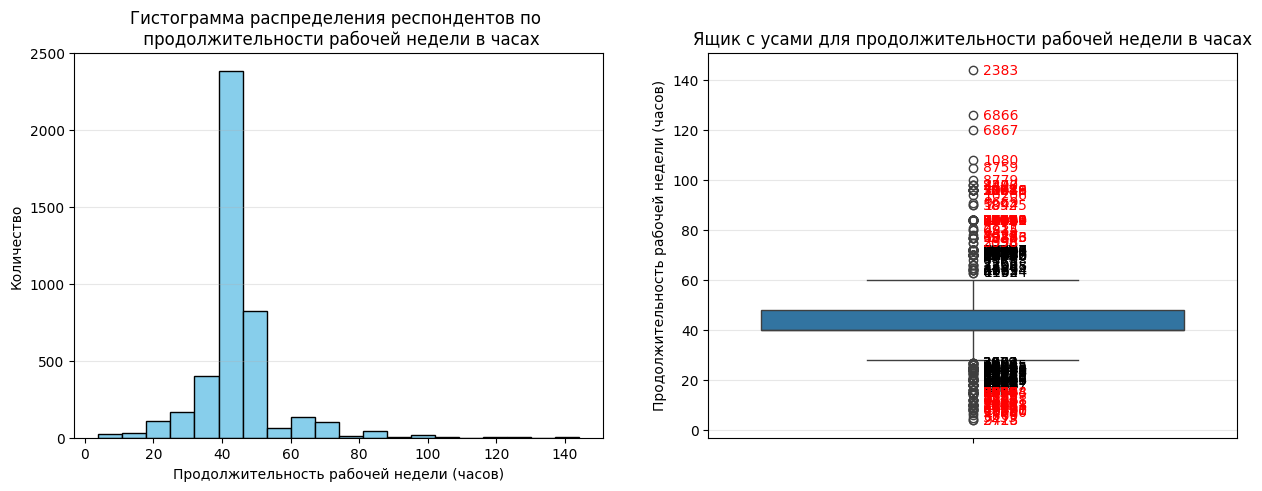

Количество экстремальных выбросов 122


In [ ]:
# Построим гистограмму ccj6_2
plt.figure(figsize=(15, 5))

plt.subplot(1,2,1)
# Построим гистограмму для ccj6_2
plt.hist(df[df['ccj6_2']!='unknown']['ccj6_2'], bins=20, edgecolor='black', color='skyblue')
plt.title('Гистограмма распределения респондентов по \n продолжительности рабочей недели в часах')
plt.xlabel('Продолжительность рабочей недели (часов)')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)

# Построим boxplot exp_curr
plt.subplot(1,2,2)
ax = sns.boxplot(df['ccj6_2'])
# Вычисляем границы выбросов
Q1 = df[df['ccj6_2']!='unknown']['ccj6_2'].quantile(0.25)
Q3 = df[df['ccj6_2']!='unknown']['ccj6_2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
lower_bound_critical = Q1 - 3 * IQR
upper_bound_critical = Q3 + 3 * IQR
# Находим выбросы
outliers = df[((df['ccj6_2']!='unknown')&((df['ccj6_2'] < lower_bound) & (df['ccj6_2'] >= lower_bound_critical) )|((df['ccj6_2'] > upper_bound) & (df['ccj6_2'] <= upper_bound_critical)))]
critical_outliers = df[(df['ccj6_2']!='unknown')&((df['ccj6_2'] < lower_bound_critical)|(df['ccj6_2'] > upper_bound_critical))]
# Подписываем точки
for index, value in outliers.iterrows():
  ax.text(0.02, value['ccj6_2'], index,
          horizontalalignment='left',
          verticalalignment='center',
          fontsize=10, color='black')
for index, value in critical_outliers.iterrows():
  ax.text(0.02, value['ccj6_2'], index,
          horizontalalignment='left',
          verticalalignment='center',
          fontsize=10, color='red')
plt.title('Ящик с усами для продолжительности рабочей недели в часах')
plt.ylabel('Продолжительность рабочей недели (часов)')
plt.grid(axis='y', alpha=0.3)

plt.show()

print("Количество экстремальных выбросов", len(critical_outliers))

##### **cc_occup08 (профессиональная группа)**

In [ ]:
# Заполним пропуски 'unknown'
df.loc[df['cc_occup08'].isnull()==True, 'cc_occup08'] = 'unknown'
df.loc[df['cc_occup08'] == 99999997, 'cc_occup08'] = 'unknown'
df.loc[df['cc_occup08'] == 99999998, 'cc_occup08'] = 'unknown'
df.loc[df['cc_occup08'] == 99999999, 'cc_occup08'] = 'unknown'
# Выведим содержимое столбца cc_occup08
print(df['cc_occup08'].value_counts())

cc_occup08
3.00        881
2.00        807
5.00        776
7.00        544
8.00        468
9.00        325
4.00        253
1.00        216
0.00         17
 unknown      7
6.00          4
Name: count, dtype: int64


In [ ]:
# Проверка
df[df['cc_occup08'].isnull()==True].shape[0]

0

In [ ]:
# Удаление строк с пропусками
df = df[df['cc_occup08']!='unknown']
df['cc_occup08'] = df['cc_occup08'].astype('float')
# Проверка
df[df['cc_occup08']=='unknown'].shape[0]

0

In [ ]:
# Категоризуем переменную по доле безработных в 2024 г по проф группам по данным Росстата
df['cc_occup08_unemploy'] = df['cc_occup08'].map(indicator_by_cc_occup08)
df['cc_occup08_unemploy'] = df['cc_occup08_unemploy'].astype('float')
# Удалим пропуски
df = df[df['cc_occup08_unemploy'].isnull()==False]

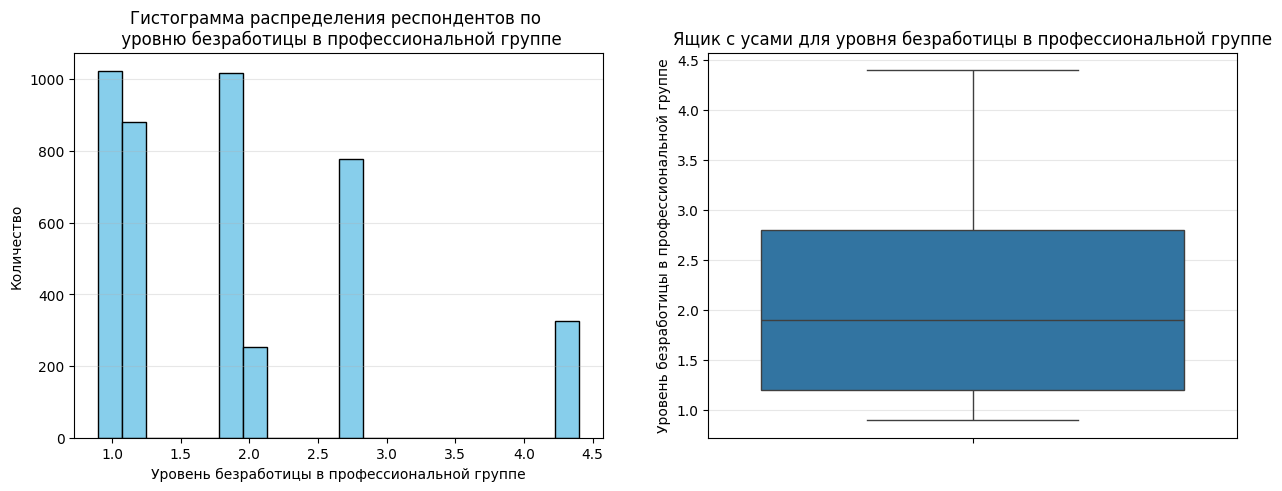

Количество экстремальных выбросов 0


In [ ]:
# Построим гистограмму cc_occup08_unemploy
plt.figure(figsize=(15, 5))

plt.subplot(1,2,1)
# Построим гистограмму для количества подчиненных
plt.hist(df[df['cc_occup08_unemploy']!='unknown']['cc_occup08_unemploy'], bins=20, edgecolor='black', color='skyblue')
plt.title('Гистограмма распределения респондентов по \n уровню безработицы в профессиональной группе')
plt.xlabel('Уровень безработицы в профессиональной группе')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)

# Построим boxplot cc_occup08_unemploy
plt.subplot(1,2,2)
ax = sns.boxplot(df['cc_occup08_unemploy'])
# Вычисляем границы выбросов
Q1 = df[df['cc_occup08_unemploy']!='unknown']['cc_occup08_unemploy'].quantile(0.25)
Q3 = df[df['cc_occup08_unemploy']!='unknown']['cc_occup08_unemploy'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
lower_bound_critical = Q1 - 3 * IQR
upper_bound_critical = Q3 + 3 * IQR
# Находим выбросы
outliers = df[((df['cc_occup08_unemploy']!='unknown')&((df['cc_occup08_unemploy'] < lower_bound) & (df['cc_occup08_unemploy'] >= lower_bound_critical) )|((df['cc_occup08_unemploy'] > upper_bound) & (df['cc_occup08_unemploy'] <= upper_bound_critical)))]
critical_outliers = df[(df['cc_occup08_unemploy']!='unknown')&((df['cc_occup08_unemploy'] < lower_bound_critical)|(df['cc_occup08_unemploy'] > upper_bound_critical))]
# Подписываем точки
for index, value in outliers.iterrows():
  ax.text(0.02, value['cc_occup08_unemploy'], index,
          horizontalalignment='left',
          verticalalignment='center',
          fontsize=10, color='black')
for index, value in critical_outliers.iterrows():
  ax.text(0.02, value['cc_occup08_unemploy'], index,
          horizontalalignment='left',
          verticalalignment='center',
          fontsize=10, color='red')
plt.title('Ящик с усами для уровня безработицы в профессиональной группе')
plt.ylabel('Уровень безработицы в профессиональной группе')
plt.grid(axis='y', alpha=0.3)

plt.show()

print("Количество экстремальных выбросов", len(critical_outliers))

##### **ccj4_1 (отрасль)**

In [ ]:
# Заполним пропуски 'unknown'
df.loc[df['ccj4_1'].isnull()==True, 'ccj4_1'] = 'unknown'
df.loc[df['ccj4_1'] == 99999997, 'ccj4_1'] = 'unknown'
df.loc[df['ccj4_1'] == 99999998, 'ccj4_1'] = 'unknown'
df.loc[df['ccj4_1'] == 99999999, 'ccj4_1'] = 'unknown'
# Выведим содержимое столбца ccj4_1
print(df['ccj4_1'].value_counts())

ccj4_1
14.00       927
10.00       461
12.00       410
7.00        372
1.00        249
6.00        240
17.00       186
5.00        177
13.00       171
3.00        136
8.00        135
9.00        112
11.00       106
2.00         92
16.00        86
15.00        84
27.00        74
4.00         61
20.00        29
23.00        24
 unknown     21
24.00        21
25.00        20
26.00        19
21.00        16
18.00        15
30.00        14
29.00         6
28.00         5
31.00         4
22.00         1
Name: count, dtype: int64


In [ ]:
# Удаление строк с пропусками
df = df[df['ccj4_1']!='unknown']
df['ccj4_1'] = df['ccj4_1'].astype('int')
# Проверка
df[df['ccj4_1']=='unknown'].shape[0]

0

In [ ]:
# Категоризуем переменную по доле занятых в 2024 г с высшим образованием по данным Росстата
df['ccj4_1_cat_educ'] = df['ccj4_1'].map(higher_ed_by_ccj4_1)
df['ccj4_1_cat_educ'] = df['ccj4_1_cat_educ'].astype('float')
# Категоризуем переменную по доле занятых в 2024 г со средним образованием по данным Росстата
df['ccj4_1_cat_educ_sec'] = df['ccj4_1'].map(secondary_ed_by_ccj4_1)
df['ccj4_1_cat_educ_sec'] = df['ccj4_1_cat_educ_sec'].astype('float')
# Категоризуем переменную по средней производительности труда в отрасли по данным Росстата
df['ccj4_1_cat_productivity'] = df['ccj4_1'].map(productivity_by_ccj4_1)
df['ccj4_1_cat_productivity'] = df['ccj4_1_cat_productivity'].astype('float')

In [ ]:
# Создадим датафрейм с информацией по отраслям
s0 = pd.Series(industry_labels, name='industry_mapping_RLMS_Rosstat')
s1 = pd.Series(higher_ed_by_ccj4_1, name='higher_ed_share')
s2 = pd.Series(secondary_ed_by_ccj4_1, name='sec_ed_share')
s3 = pd.Series(productivity_by_ccj4_1, name='productivity')
df_industry = pd.concat([s0, s1, s2, s3], axis=1)

# Построим трехмерную диаграмму
fig = px.scatter_3d(
    df_industry,
    x='higher_ed_share',          # ось X
    y='sec_ed_share',             # ось Y
    z='productivity',             # ось Z
    size='productivity',          # размер пузырька
    color='productivity',         # цвет пузырька (можно заменить на кластер)
    text=df_industry.index,       # подписи точек
    hover_name=df_industry.index, # код отрасли во всплывающей подсказке
    hover_data={
        'industry_mapping_RLMS_Rosstat': True,  # показать эту колонку
        'higher_ed_share': ':.1f',              # с форматом
        'sec_ed_share': ':.1f',
        'productivity': ':,.0f'
    },
    title='3D-взаимосвязь: образование, среднее образование и производительность'
)

# Настройка размера пузырьков
fig.update_traces(
    marker=dict(
        sizemode='area',
        sizeref=2. * max(df_industry['productivity']) / (40**2),
        sizemin=4,
        opacity=0.8
    ),
    textposition='top center',
    textfont=dict(size=9)
)

# Настройка осей и фона
fig.update_layout(
    scene=dict(
        xaxis_title='Высшее образование, %',
        yaxis_title='Среднее образование, %',
        zaxis_title='Производительность труда',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

Видим, что все отрасли по производительности и образованию делятся на 3-4 кластера. Очивидные выбросы - отрасли 4, 18.

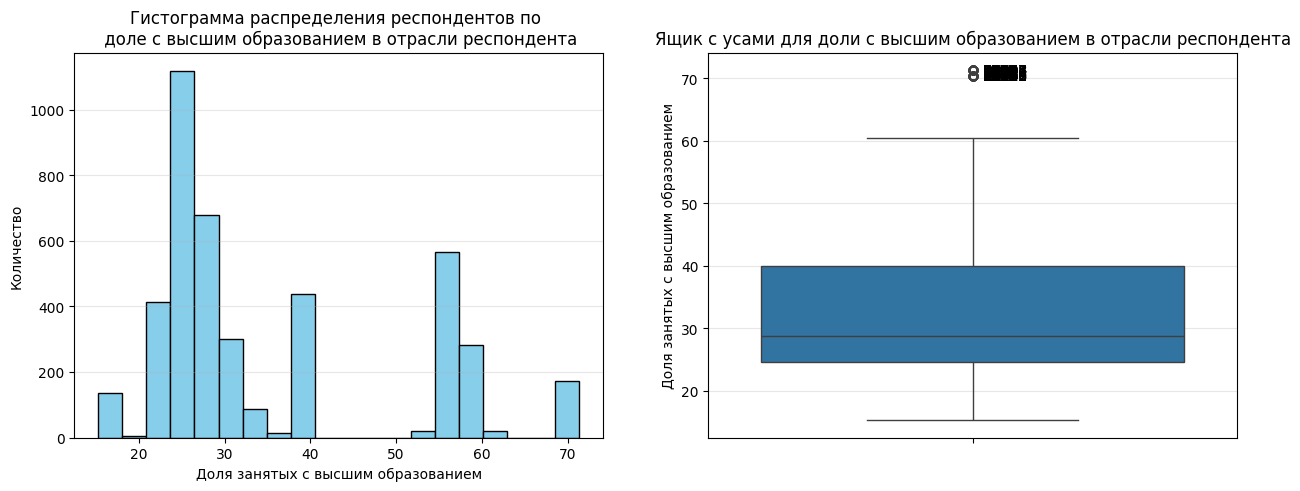

Количество экстремальных выбросов 0


In [ ]:
# Построим гистограмму ccj4_1_cat_educ
plt.figure(figsize=(15, 5))

plt.subplot(1,2,1)
# Построим гистограмму для количества подчиненных
plt.hist(df[df['ccj4_1_cat_educ']!='unknown']['ccj4_1_cat_educ'], bins=20, edgecolor='black', color='skyblue')
plt.title('Гистограмма распределения респондентов по \n доле с высшим образованием в отрасли респондента')
plt.xlabel('Доля занятых с высшим образованием')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)

# Построим boxplot ccj4_1_cat_educ
plt.subplot(1,2,2)
ax = sns.boxplot(df['ccj4_1_cat_educ'])
# Вычисляем границы выбросов
Q1 = df[df['ccj4_1_cat_educ']!='unknown']['ccj4_1_cat_educ'].quantile(0.25)
Q3 = df[df['ccj4_1_cat_educ']!='unknown']['ccj4_1_cat_educ'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
lower_bound_critical = Q1 - 3 * IQR
upper_bound_critical = Q3 + 3 * IQR
# Находим выбросы
outliers = df[((df['ccj4_1_cat_educ']!='unknown')&((df['ccj4_1_cat_educ'] < lower_bound) & (df['ccj4_1_cat_educ'] >= lower_bound_critical) )|((df['ccj4_1_cat_educ'] > upper_bound) & (df['ccj4_1_cat_educ'] <= upper_bound_critical)))]
critical_outliers = df[(df['ccj4_1_cat_educ']!='unknown')&((df['ccj4_1_cat_educ'] < lower_bound_critical)|(df['ccj4_1_cat_educ'] > upper_bound_critical))]
# Подписываем точки
for index, value in outliers.iterrows():
  ax.text(0.02, value['ccj4_1_cat_educ'], index,
          horizontalalignment='left',
          verticalalignment='center',
          fontsize=10, color='black')
for index, value in critical_outliers.iterrows():
  ax.text(0.02, value['ccj4_1_cat_educ'], index,
          horizontalalignment='left',
          verticalalignment='center',
          fontsize=10, color='red')
plt.title('Ящик с усами для доли с высшим образованием в отрасли респондента')
plt.ylabel('Доля занятых с высшим образованием')
plt.grid(axis='y', alpha=0.3)

plt.show()

print("Количество экстремальных выбросов", len(critical_outliers))

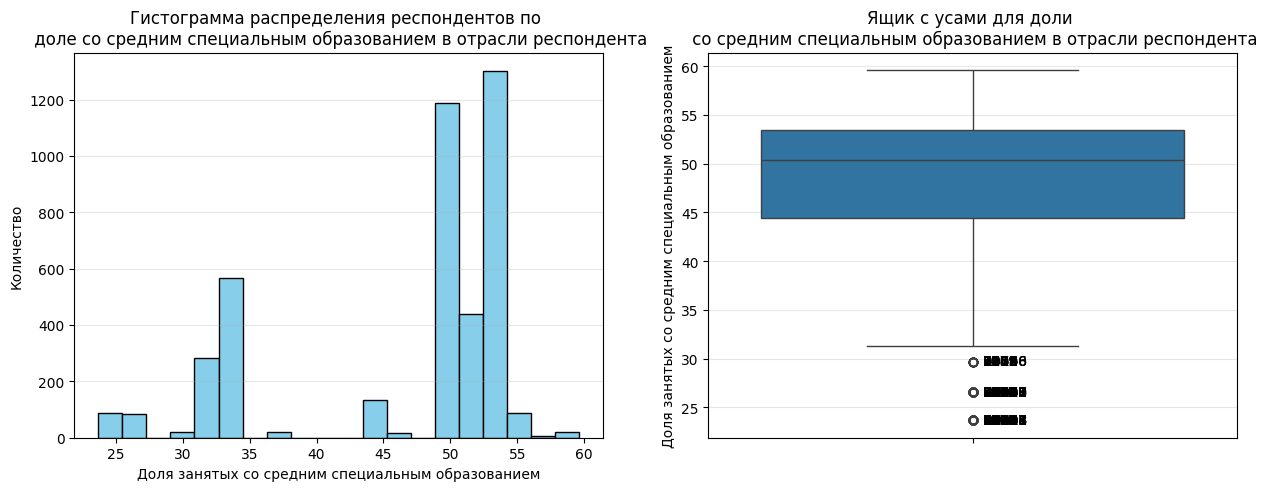

Количество экстремальных выбросов 0


In [ ]:
# Построим гистограмму ccj4_1_cat_educ_sec
plt.figure(figsize=(15, 5))

plt.subplot(1,2,1)
# Построим гистограмму для количества подчиненных
plt.hist(df[df['ccj4_1_cat_educ_sec']!='unknown']['ccj4_1_cat_educ_sec'], bins=20, edgecolor='black', color='skyblue')
plt.title('Гистограмма распределения респондентов по \n доле со средним специальным образованием в отрасли респондента')
plt.xlabel('Доля занятых со средним специальным образованием')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)

# Построим boxplot ccj4_1_cat_educ_sec
plt.subplot(1,2,2)
ax = sns.boxplot(df['ccj4_1_cat_educ_sec'])
# Вычисляем границы выбросов
Q1 = df[df['ccj4_1_cat_educ_sec']!='unknown']['ccj4_1_cat_educ_sec'].quantile(0.25)
Q3 = df[df['ccj4_1_cat_educ_sec']!='unknown']['ccj4_1_cat_educ_sec'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
lower_bound_critical = Q1 - 3 * IQR
upper_bound_critical = Q3 + 3 * IQR
# Находим выбросы
outliers = df[((df['ccj4_1_cat_educ_sec']!='unknown')&((df['ccj4_1_cat_educ_sec'] < lower_bound) & (df['ccj4_1_cat_educ_sec'] >= lower_bound_critical) )|((df['ccj4_1_cat_educ_sec'] > upper_bound) & (df['ccj4_1_cat_educ_sec'] <= upper_bound_critical)))]
critical_outliers = df[(df['ccj4_1_cat_educ_sec']!='unknown')&((df['ccj4_1_cat_educ_sec'] < lower_bound_critical)|(df['ccj4_1_cat_educ_sec'] > upper_bound_critical))]
# Подписываем точки
for index, value in outliers.iterrows():
  ax.text(0.02, value['ccj4_1_cat_educ_sec'], index,
          horizontalalignment='left',
          verticalalignment='center',
          fontsize=10, color='black')
for index, value in critical_outliers.iterrows():
  ax.text(0.02, value['ccj4_1_cat_educ_sec'], index,
          horizontalalignment='left',
          verticalalignment='center',
          fontsize=10, color='red')
plt.title('Ящик с усами для доли \n со средним специальным образованием в отрасли респондента')
plt.ylabel('Доля занятых со средним специальным образованием')
plt.grid(axis='y', alpha=0.3)

plt.show()

print("Количество экстремальных выбросов", len(critical_outliers))

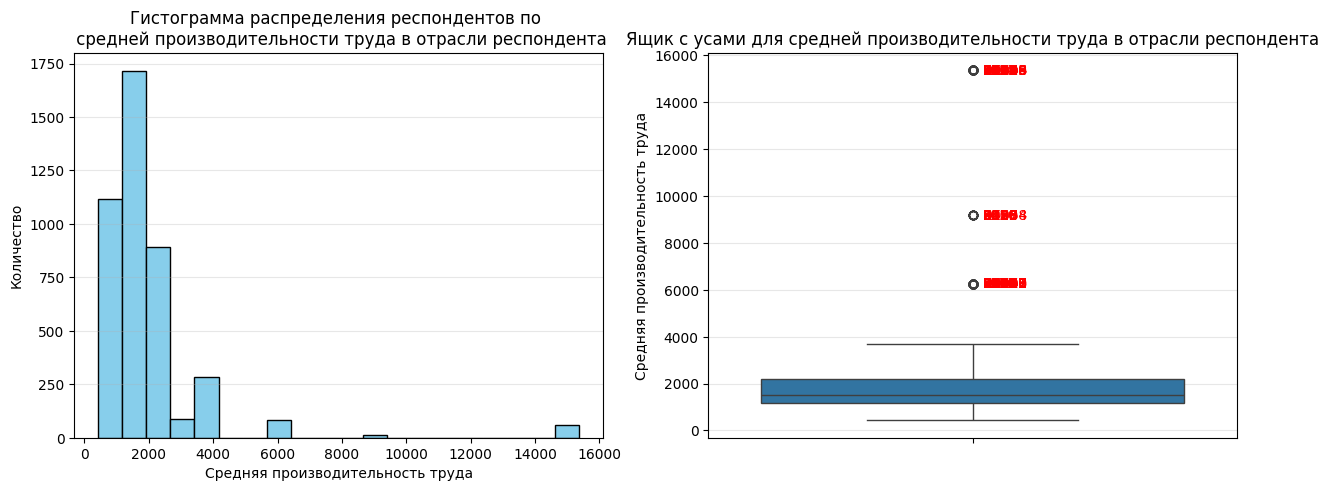

Количество экстремальных выбросов 160


In [ ]:
# Построим гистограмму ccj4_1_cat_productivity
plt.figure(figsize=(15, 5))

plt.subplot(1,2,1)
# Построим гистограмму для количества подчиненных
plt.hist(df[df['ccj4_1_cat_productivity']!='unknown']['ccj4_1_cat_productivity'], bins=20, edgecolor='black', color='skyblue')
plt.title('Гистограмма распределения респондентов по \n средней производительности труда в отрасли респондента')
plt.xlabel('Средняя производительность труда')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)

# Построим boxplot ccj4_1_cat_productivity
plt.subplot(1,2,2)
ax = sns.boxplot(df['ccj4_1_cat_productivity'])
# Вычисляем границы выбросов
Q1 = df[df['ccj4_1_cat_productivity']!='unknown']['ccj4_1_cat_productivity'].quantile(0.25)
Q3 = df[df['ccj4_1_cat_productivity']!='unknown']['ccj4_1_cat_productivity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
lower_bound_critical = Q1 - 3 * IQR
upper_bound_critical = Q3 + 3 * IQR
# Находим выбросы
outliers = df[((df['ccj4_1_cat_productivity']!='unknown')&((df['ccj4_1_cat_productivity'] < lower_bound) & (df['ccj4_1_cat_productivity'] >= lower_bound_critical) )|((df['ccj4_1_cat_productivity'] > upper_bound) & (df['ccj4_1_cat_productivity'] <= upper_bound_critical)))]
critical_outliers = df[(df['ccj4_1_cat_productivity']!='unknown')&((df['ccj4_1_cat_productivity'] < lower_bound_critical)|(df['ccj4_1_cat_productivity'] > upper_bound_critical))]
# Подписываем точки
for index, value in outliers.iterrows():
  ax.text(0.02, value['ccj4_1_cat_productivity'], index,
          horizontalalignment='left',
          verticalalignment='center',
          fontsize=10, color='black')
for index, value in critical_outliers.iterrows():
  ax.text(0.02, value['ccj4_1_cat_productivity'], index,
          horizontalalignment='left',
          verticalalignment='center',
          fontsize=10, color='red')
plt.title('Ящик с усами для средней производительности труда в отрасли респондента')
plt.ylabel('Средняя производительность труда')
plt.grid(axis='y', alpha=0.3)

plt.show()

print("Количество экстремальных выбросов", len(critical_outliers))

In [ ]:
# Удалим выбросы по отраслям
df = df[df['ccj4_1']!=4]
df = df[df['ccj4_1']!=18]

##### **ccj6_0 (количество подчиненных)**

In [ ]:
# Заполним пропуски 'unknown'
df.loc[df['ccj6']==2, 'ccj6_0'] = 0
df.loc[df['ccj6_0'].isnull()==True, 'ccj6_0'] = 'unknown'
df.loc[df['ccj6_0'] == 99999997, 'ccj6_0'] = 'unknown'
df.loc[df['ccj6_0'] == 99999998, 'ccj6_0'] = 'unknown'
df.loc[df['ccj6_0'] == 99999999, 'ccj6_0'] = 'unknown'
# Удалим ненужные столбцы
del df['ccj6']
# Выведим содержимое столбца ccj6_cat
print(df['ccj6_0'].value_counts())

ccj6_0
0.00        3493
2.00          86
3.00          77
1.00          73
5.00          70
4.00          53
10.00         46
6.00          45
15.00         33
8.00          23
20.00         18
12.00         17
40.00         16
7.00          14
30.00         14
9.00          13
 unknown      11
18.00          8
25.00          8
50.00          4
14.00          4
16.00          3
45.00          3
60.00          3
11.00          3
24.00          3
17.00          3
100.00         3
200.00         2
19.00          2
23.00          2
49.00          2
28.00          2
21.00          2
300.00         1
22.00          1
90.00          1
31.00          1
26.00          1
58.00          1
36.00          1
37.00          1
130.00         1
56.00          1
210.00         1
35.00          1
150.00         1
32.00          1
54.00          1
116.00         1
52.00          1
34.00          1
Name: count, dtype: int64


In [ ]:
# Проверка
df[df['ccj6_0'].isnull()==True].shape[0]

0

In [ ]:
# Проверка
df[df['ccj6_0']=='unknown'].shape[0]

11

In [ ]:
# Удаление строк с пропусками
df = df[df['ccj6_0']!='unknown']
df['ccj6_0'] = df['ccj6_0'].astype('float')
# Проверка
df[df['ccj6_0']=='unknown'].shape[0]

0

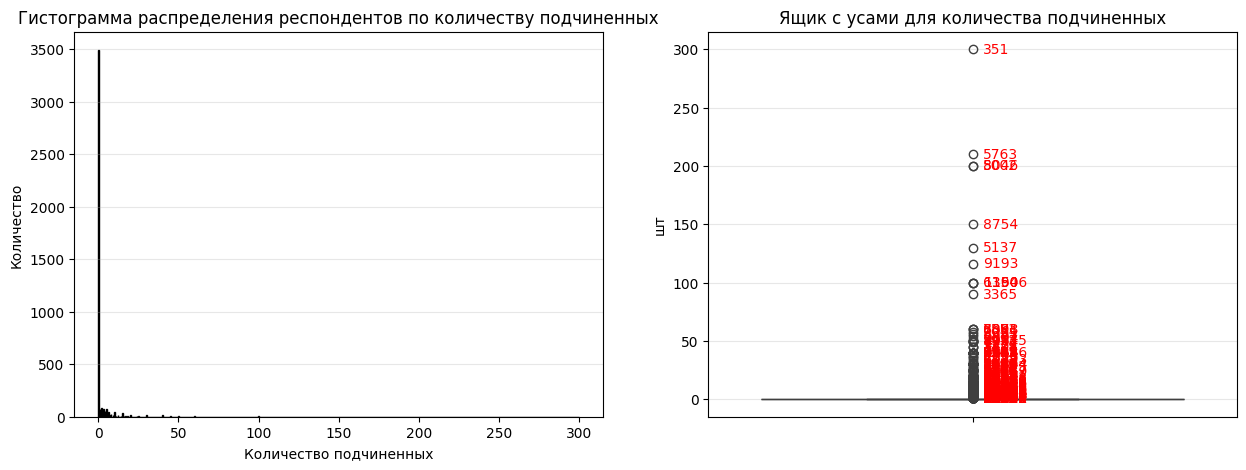

Количество экстремальных выбросов 673


In [ ]:
# Построим гистограмму ccj6_0
plt.figure(figsize=(15, 5))

plt.subplot(1,2,1)
# Построим гистограмму для количества подчиненных
plt.hist(df[df['ccj6_0']!='unknown']['ccj6_0'], bins=1000, edgecolor='black', color='skyblue')
plt.title('Гистограмма распределения респондентов по количеству подчиненных')
plt.xlabel('Количество подчиненных')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)

# Построим boxplot ccj6_0
plt.subplot(1,2,2)
ax = sns.boxplot(df['ccj6_0'])
# Вычисляем границы выбросов
Q1 = df[df['ccj6_0']!='unknown']['ccj6_0'].quantile(0.25)
Q3 = df[df['ccj6_0']!='unknown']['ccj6_0'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
lower_bound_critical = Q1 - 3 * IQR
upper_bound_critical = Q3 + 3 * IQR
# Находим выбросы
outliers = df[((df['ccj6_0']!='unknown')&((df['ccj6_0'] < lower_bound) & (df['ccj6_0'] >= lower_bound_critical) )|((df['ccj6_0'] > upper_bound) & (df['ccj6_0'] <= upper_bound_critical)))]
critical_outliers = df[(df['ccj6_0']!='unknown')&((df['ccj6_0'] < lower_bound_critical)|(df['ccj6_0'] > upper_bound_critical))]
# Подписываем точки
for index, value in outliers.iterrows():
  ax.text(0.02, value['ccj6_0'], index,
          horizontalalignment='left',
          verticalalignment='center',
          fontsize=10, color='black')
for index, value in critical_outliers.iterrows():
  ax.text(0.02, value['ccj6_0'], index,
          horizontalalignment='left',
          verticalalignment='center',
          fontsize=10, color='red')
plt.title('Ящик с усами для количества подчиненных')
plt.ylabel('шт')
plt.grid(axis='y', alpha=0.3)

plt.show()

print("Количество экстремальных выбросов", len(critical_outliers))

In [ ]:
upper_bound_critical

np.float64(0.0)

In [ ]:
# Закодируем переменную для эллиминирования влияния выбросов
df['ccj6_0_cat'] = np.where(df['ccj6_0'] == 0, 0, 1)

##### **ccj13 (сколько человек работает на вашем предприятии)**

In [ ]:
# Заполним пропуски 'unknown'
df.loc[df['ccj13'].isnull()==True, 'ccj13'] = 'unknown'
df.loc[df['ccj13'] == 99999997, 'ccj13'] = 'unknown'
df.loc[df['ccj13'] == 99999998, 'ccj13'] = 'unknown'
df.loc[df['ccj13'] == 99999999, 'ccj13'] = 'unknown'
# Выведим содержимое столбца ccj13
print(df['ccj13'].value_counts())

ccj13
 unknown      1253
97.00          198
30.00          163
20.00          161
50.00          144
              ... 
78.00            1
88.00            1
290.00           1
300,000.00       1
100,000.00       1
Name: count, Length: 181, dtype: int64


In [ ]:
# Удаление строк с пропусками
df = df[df['ccj13']!='unknown']
df['ccj13'] = df['ccj13'].astype('float')
# Проверка
df[df['ccj13']=='unknown'].shape[0]

0

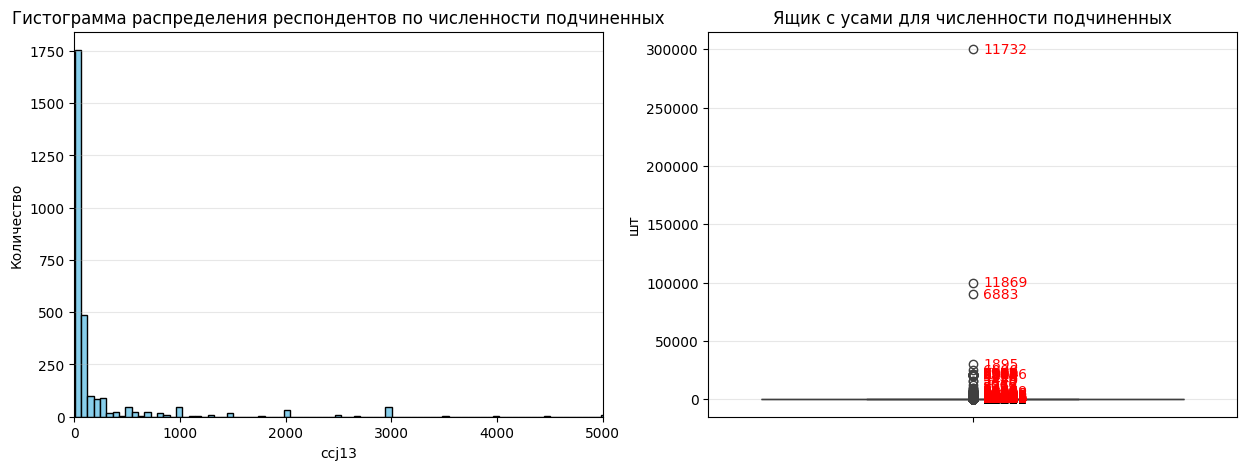

Количество экстремальных выбросов 386


In [ ]:
# Построим гистограмму ccj6_0
plt.figure(figsize=(15, 5))

plt.subplot(1,2,1)
# Построим гистограмму для численности подчиненных
plt.hist(df[df['ccj13']!='unknown']['ccj13'], bins=5000, edgecolor='black', color='skyblue')
plt.title('Гистограмма распределения респондентов по численности подчиненных')
plt.xlabel('ccj13')
plt.xlim(0, 5000)
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)

# Построим boxplot ccj13
plt.subplot(1,2,2)
ax = sns.boxplot(df['ccj13'])
# Вычисляем границы выбросов
Q1 = df[df['ccj13']!='unknown']['ccj13'].quantile(0.25)
Q3 = df[df['ccj13']!='unknown']['ccj13'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
lower_bound_critical = Q1 - 3 * IQR
upper_bound_critical = Q3 + 3 * IQR
# Находим выбросы
outliers = df[((df['ccj13']!='unknown')&((df['ccj13'] < lower_bound) & (df['ccj13'] >= lower_bound_critical) )|((df['ccj13'] > upper_bound) & (df['ccj13'] <= upper_bound_critical)))]
critical_outliers = df[(df['ccj13']!='unknown')&((df['ccj13'] < lower_bound_critical)|(df['ccj13'] > upper_bound_critical))]
# Подписываем точки
for index, value in outliers.iterrows():
  ax.text(0.02, value['ccj13'], index,
          horizontalalignment='left',
          verticalalignment='center',
          fontsize=10, color='black')
for index, value in critical_outliers.iterrows():
  ax.text(0.02, value['ccj13'], index,
          horizontalalignment='left',
          verticalalignment='center',
          fontsize=10, color='red')
plt.title('Ящик с усами для численности подчиненных')
plt.ylabel('шт')
#plt.ylim(0, 5000)
plt.grid(axis='y', alpha=0.3)

plt.show()

print("Количество экстремальных выбросов", len(critical_outliers))

In [ ]:
upper_bound_critical

np.float64(355.0)

In [ ]:
df = df[df['ccj13']<=upper_bound_critical]

##### **Итоги изучения и предобработки фичей**

In [ ]:
# Удалим ненужные далее столбцы
del df['ccid_i'] # id
del df['cc_occup08']
del df['ccj4_1']
del df['ccj6_0']

In [ ]:
df.head()

,ccj6_2,ccj13,ccj10,ccj10_cat,cc_occup08_unemploy,ccj4_1_cat_educ,ccj4_1_cat_educ_sec,ccj4_1_cat_productivity,ccj6_0_cat
9,40.00,20.00,"45,000.00",0,1.20,56.30,33.50,"2,020.00",0
16,40.00,30.00,"130,000.00",0,1.00,57.20,33.50,852.00,0
20,48.00,50.00,"20,000.00",1,2.80,40.00,51.10,"1,101.00",0
24,40.00,30.00,"35,000.00",0,4.40,24.60,50.40,"1,502.00",0
31,42.00,50.00,"22,000.00",1,1.90,40.00,51.10,"1,101.00",0


In [ ]:
# Выведим общую информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2527 entries, 9 to 11997
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ccj6_2                   2527 non-null   float64
 1   ccj13                    2527 non-null   float64
 2   ccj10                    2527 non-null   float64
 3   ccj10_cat                2527 non-null   int64  
 4   cc_occup08_unemploy      2527 non-null   float64
 5   ccj4_1_cat_educ          2527 non-null   float64
 6   ccj4_1_cat_educ_sec      2527 non-null   float64
 7   ccj4_1_cat_productivity  2527 non-null   float64
 8   ccj6_0_cat               2527 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 197.4 KB


Итак, первоначально датасет содержал  данные о 12 тыс респондентов. Поскольку цель - кластеризация для уточнения модели прогноза заработной платы за последние 30 дней, то из датасета были удалены:
 - не имеющие работу (ccj77==1),
 - инвалиды (ccm20_7==2)),
 - ученики, пенсионеры, студенты, ... (ccj90>=10&ccj90<=13),
 - ненадежные ответы респондентов (ccs7==1),
 - не указавшие размер заработной платы за последние 30 дней (ccj10!=unknown),
 - пропуски по фичам:

|Фичи|Пропуски|Выбросы (экстримальные)|
|------|------|------|
|ccj6_2 (продолжительность рабочей недели в часах)|Есть (категория 'unknown'-518)|122|
|cc_occup08 (профессиональная группа)|Есть (категория 'unknown'-7)|нет|
|ccj4_1 (отрасль)|Есть (категория 'unknown'-7)|есть для производительности - 160|
|ccj6_0 (количество подчиненных)|Есть (категория 'unknown'-11)|690|
|ccj13 (численность сотрудников)|Есть (категория 'unknown'-1270)|401|

 - экстримальные выбросы по производительности отраслей (убрали отрасли: 4, 8),
 - экстримальные выбросы по ccj13 (сколько человек работает на вашем предприятии).

 В результате, в итоговой выборке осталось 2527 респондентов.

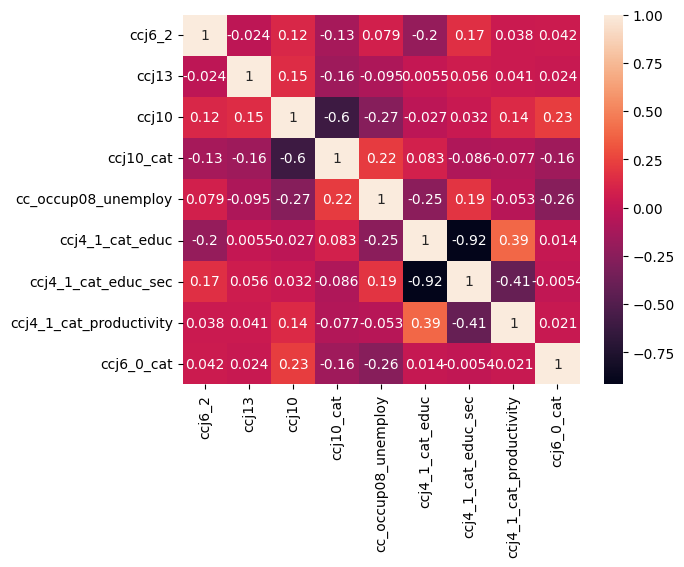

In [ ]:
# Построим парные корреляции Пирсона
sns.heatmap(df.corr(), annot = True);

In [ ]:
df_f = df.copy()
# Удалим ненужные далее столбцы
del df['ccj4_1_cat_educ_sec'] # сильная корреляция с ccj4_1_cat_educ
del df['ccj10']

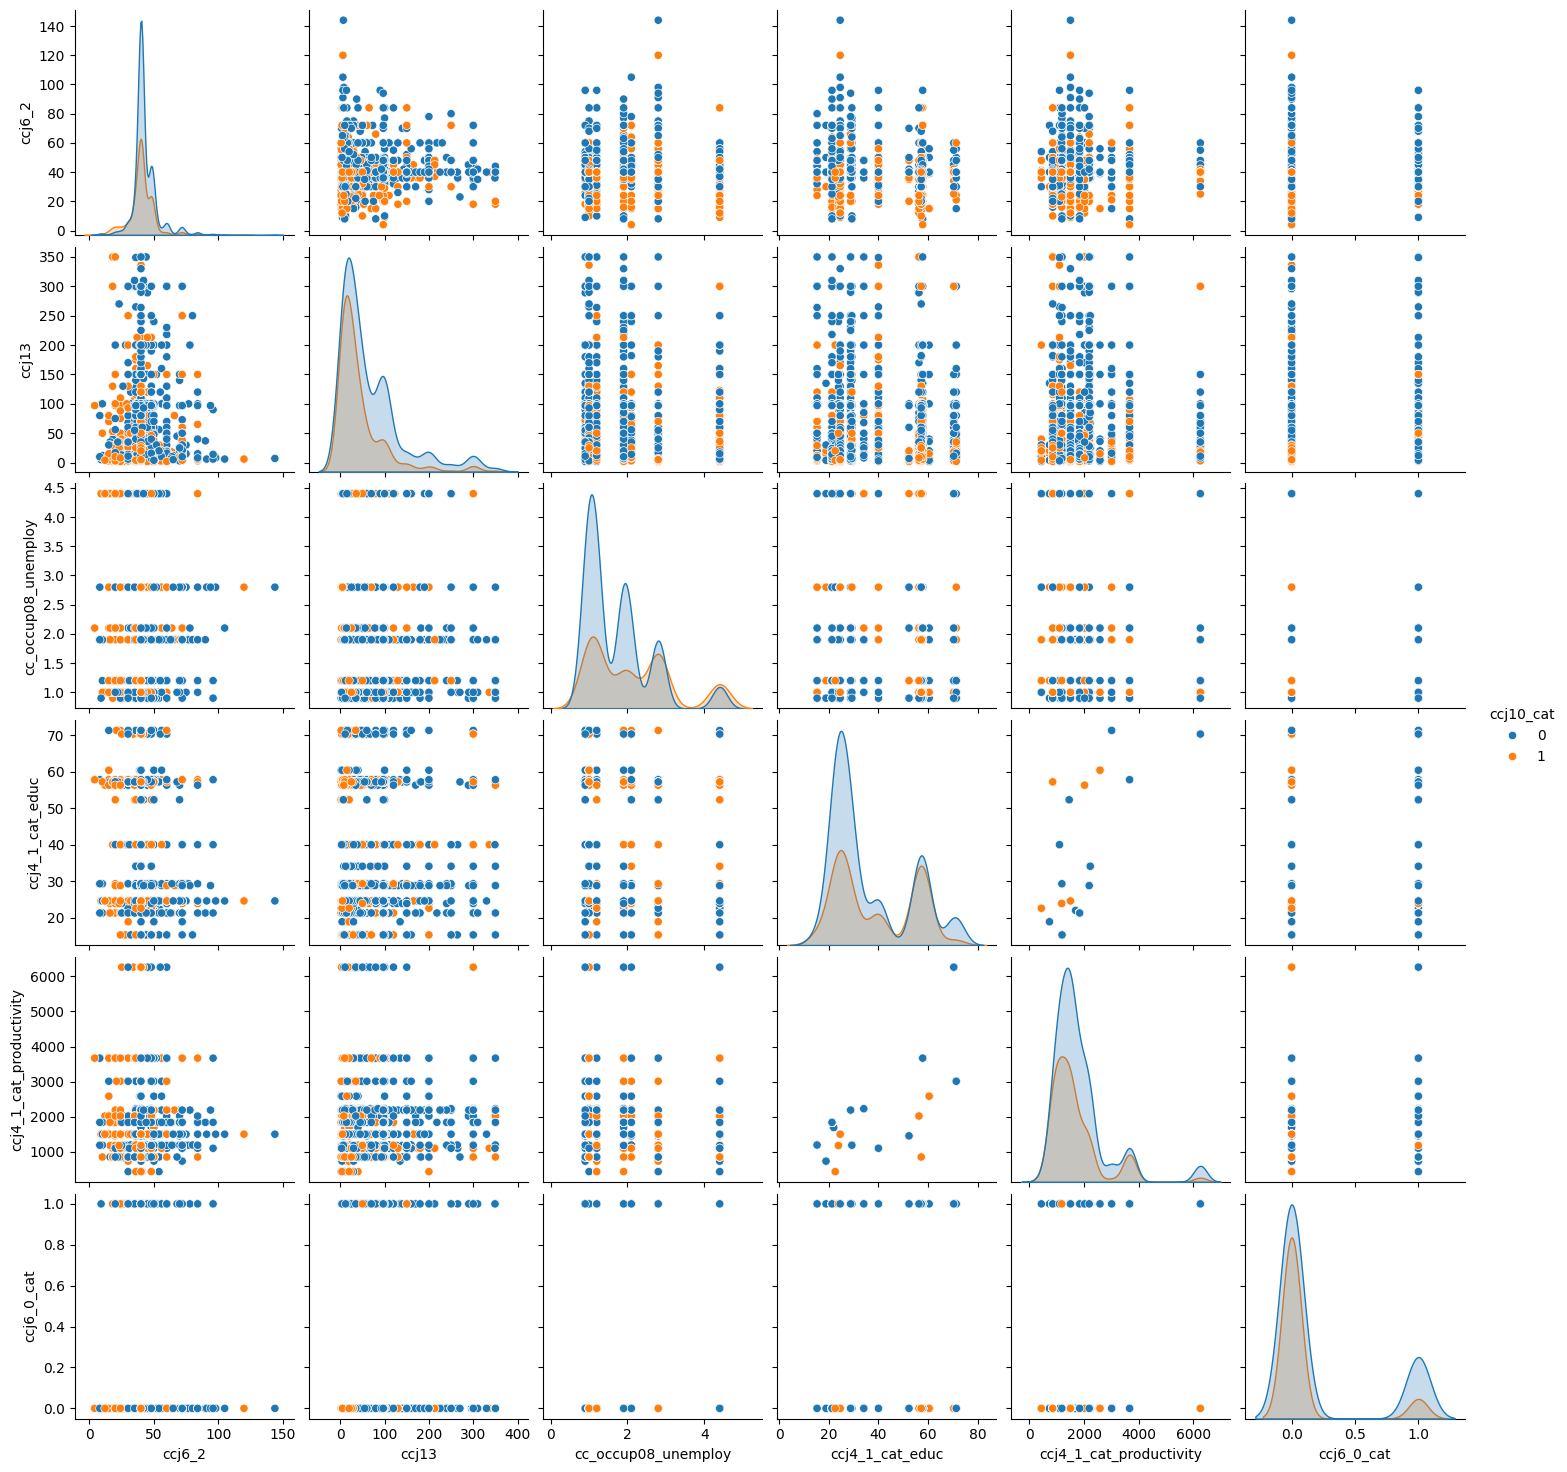

In [ ]:
# Визуализируем признаки попарно
sns.pairplot(df, hue='ccj10_cat');

In [ ]:
# Удалим ненужные далее столбцы
del df['ccj10_cat']

In [ ]:
df.head()

,ccj6_2,ccj13,cc_occup08_unemploy,ccj4_1_cat_educ,ccj4_1_cat_productivity,ccj6_0_cat
9,40.00,20.00,1.20,56.30,"2,020.00",0
16,40.00,30.00,1.00,57.20,852.00,0
20,48.00,50.00,2.80,40.00,"1,101.00",0
24,40.00,30.00,4.40,24.60,"1,502.00",0
31,42.00,50.00,1.90,40.00,"1,101.00",0


#### **Трансформация переменных**

In [ ]:
# Трансформируем признаки в шкалу от 0 до 1
scaler = MinMaxScaler()
scaled_df = scaler.fit_transform(df)

In [ ]:
scaled_df_ = pd.DataFrame(scaled_df)
scaled_df_.columns = df.columns

In [ ]:
scaled_df_.head()

,ccj6_2,ccj13,cc_occup08_unemploy,ccj4_1_cat_educ,ccj4_1_cat_productivity,ccj6_0_cat
0,0.26,0.05,0.09,0.73,0.27,0.00
1,0.26,0.08,0.03,0.75,0.07,0.00
2,0.31,0.14,0.54,0.44,0.11,0.00
3,0.26,0.08,1.00,0.17,0.18,0.00
4,0.27,0.14,0.29,0.44,0.11,0.00


In [ ]:
# Построим трехмерную диаграмму
fig = px.scatter_3d(
    scaled_df_,
    x='ccj4_1_cat_educ',
    y='ccj4_1_cat_productivity',
    z='cc_occup08_unemploy',
    color='ccj6_2',
    hover_name=scaled_df_.index,
    title='3D-взаимосвязь между долей высшего образования, производительностью труда, уровнем безработицы и продолжительностью рабочей недели'
)
fig.show()

На диаграмме отчетливо видны четыре кластера.

In [ ]:
# Построим трехмерную диаграмму
fig = px.scatter_3d(
    scaled_df_,
    x='ccj4_1_cat_educ',
    y='ccj4_1_cat_productivity',
    z='ccj6_0_cat',
    color='ccj6_2',
    hover_name=scaled_df_.index,
    title='3D-взаимосвязь между долей высшего образования, производительностью труда, количеством подчиненных и продолжительностью рабочей недели'
)
fig.show()

In [ ]:
# Построим трехмерную диаграмму
fig = px.scatter_3d(
    scaled_df_,
    x='ccj4_1_cat_educ',
    y='ccj4_1_cat_productivity',
    z='ccj13',
    color='ccj6_2',
    hover_name=scaled_df_.index,
    title='3D-взаимосвязь между долей высшего образования, производительностью труда, количеством работников и продолжительностью рабочей недели'
)
fig.show()

In [ ]:
# Построим трехмерную диаграмму
fig = px.scatter_3d(
    scaled_df_,
    x='ccj4_1_cat_educ',
    y='ccj4_1_cat_productivity',
    z='ccj6_2',
    color='ccj6_2',
    hover_name=scaled_df_.index,
    title='3D-взаимосвязь между долей высшего образования, производительностью труда и продолжительностью рабочей недели'
)
fig.show()

Видим, что данные неоднородны. Исходя из вышепредставленных графиков, можно сделать вывод о том, что оптимальное количество кластеров от 8 до 16. Для точного определения воспользуемся кластерными алгоритмами.

#### **Кластеризация**

##### **Иерархическая кластеризация**

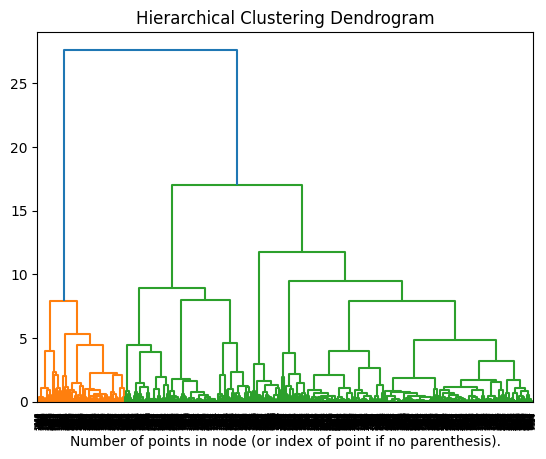

In [ ]:
def plot_dendrogram(model, **kwargs):

    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)


model = AgglomerativeClustering(distance_threshold=100, n_clusters=None)

model = model.fit(scaled_df)
plt.title("Hierarchical Clustering Dendrogram")
plot_dendrogram(model)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

Для определения, какое количество кластеров следовало бы считать оптимальным, можно проанализировать дендрограмму. На этапе, где эта мера расстояния между двумя кластерами увеличивается скачкообразно, процесс объединения в новые кластеры необходимо остановить, так как в противном случае были бы объединены уже кластеры, находящиеся на относительно большом расстоянии друг от друга. В данном примере оптимальный порог примерно 4-5 и количество кластеров примерно 10-16.

Проверим выдвинутую гипотезу о числе кластеров, применив метод кластерного анализа «k-средних».

##### **k-means**

Найдем оптимальное число кластеров используя метод elbow. Источники:
- https://en.wikipedia.org/wiki/Elbow_method_(clustering)
- https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/

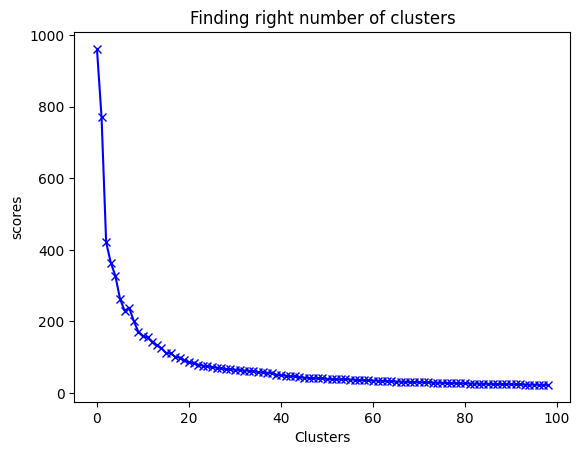

In [ ]:
scores = []

range_values = range(1,100)

for i in range_values:
  kmeans = KMeans(n_clusters = i, init='k-means++', random_state=random_state)
  kmeans.fit(scaled_df)
  scores.append(kmeans.inertia_)

plt.plot(scores, 'bx-')
plt.title('Finding right number of clusters')
plt.xlabel('Clusters')
plt.ylabel('scores')
plt.show()

Согласно графику 10-16-й кластер, по-видимому, образует изгиб кривой. Применим также метрику [silhouette_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html#sklearn.metrics.silhouette_score).

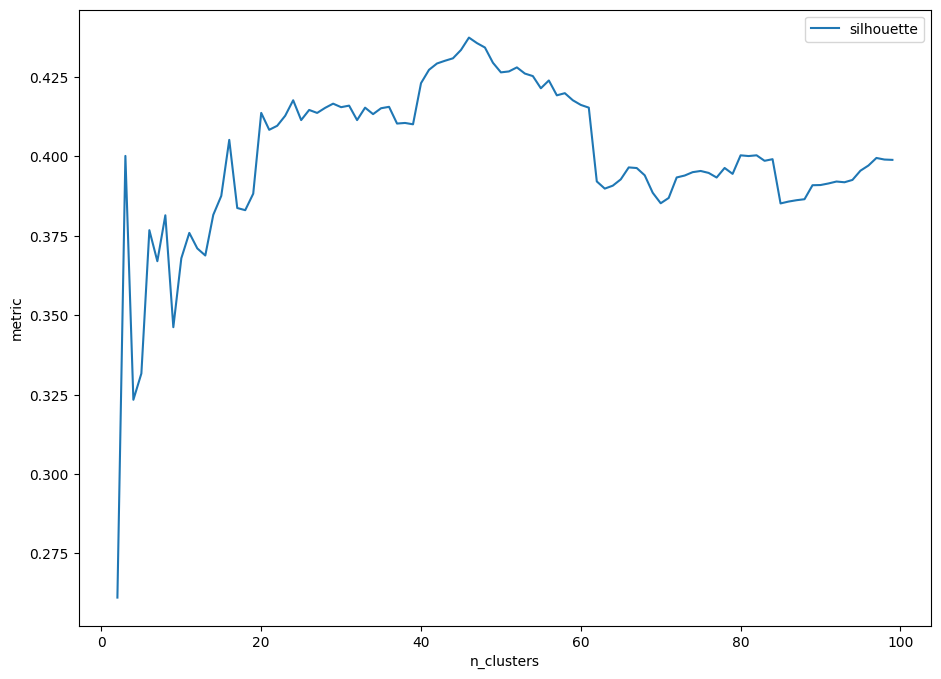

In [ ]:
silhouette = []
for n_c in range(2,100):
    k_means = KMeans(n_clusters = n_c, init='k-means++', random_state=random_state)
    k_means = k_means.fit(scaled_df)
    clusters = k_means.predict(scaled_df)
    silhouette.append(silhouette_score(scaled_df, clusters))

plt.figure(figsize=(11, 8))
plt.plot(range(2,100), silhouette, label='silhouette')
plt.xlabel('n_clusters')
plt.ylabel('metric')
plt.legend(loc='best')
plt.show()

Для итогового выбора количества кластеров используем elbow. Выберем количество кластеров равным 10, 12 и 16 и остановимся там, где результаты получаться наиболее интерпретируемыми и соответсвующими бизнес-логике.

###### **k-means, количество кластеров 10**

In [ ]:
# Обучим k-means с количеством кластеров 10
k_means = KMeans(n_clusters = 10, init='k-means++', random_state=random_state)
k_means = k_means.fit(scaled_df)
# Для каждого респондента определим кластер
clusters = k_means.predict(scaled_df)
labels = k_means.labels_ # Сохраним метки кластера
# Проверка
print(labels.max(), labels.min())

9 0


In [ ]:
k_means.cluster_centers_.shape

(10, 6)

In [ ]:
# Сохраним координаты центров кластеров
cluster_centers = pd.DataFrame(data = k_means.cluster_centers_, columns = [df.columns])

# Чтобы понять, что означают эти числа, выполним обратное преобразование
cluster_centers = scaler.inverse_transform(cluster_centers)
cluster_centers = pd.DataFrame(data = cluster_centers, columns = [df.columns])
cluster_centers

,ccj6_2,ccj13,cc_occup08_unemploy,ccj4_1_cat_educ,ccj4_1_cat_productivity,ccj6_0_cat
0,40.96,57.06,1.19,70.30,"6,263.00",-0.00
1,44.79,59.73,1.49,25.43,"1,615.81",1.00
2,44.67,33.96,2.29,25.36,"1,576.40",0.00
3,41.62,39.95,3.25,57.55,"2,110.09",0.00
4,37.55,49.98,1.19,58.65,"1,868.65",0.00
5,38.90,66.52,1.04,50.57,"1,170.74",1.00
6,42.87,66.15,1.23,63.09,"4,020.63",1.00
7,39.61,73.27,4.40,26.25,"1,586.99",0.00
8,41.39,48.47,1.15,30.06,"1,397.66",0.00
9,42.03,239.38,1.61,32.04,"1,692.90",0.00


In [ ]:
# Объединим метки кластеров с исходным датафреймом
df_ = scaler.inverse_transform(scaled_df)
df_ = pd.DataFrame(data = df_, columns = df.columns)
df_cluster = pd.concat([df_, pd.DataFrame({'cluster':labels})], axis = 1)
df_cluster.head(5)

,ccj6_2,ccj13,cc_occup08_unemploy,ccj4_1_cat_educ,ccj4_1_cat_productivity,ccj6_0_cat,cluster
0,40.00,20.00,1.20,56.30,"2,020.00",0.00,4
1,40.00,30.00,1.00,57.20,852.00,0.00,4
2,48.00,50.00,2.80,40.00,"1,101.00",0.00,2
3,40.00,30.00,4.40,24.60,"1,502.00",0.00,7
4,42.00,50.00,1.90,40.00,"1,101.00",0.00,8


In [ ]:
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2527 entries, 0 to 2526
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ccj6_2                   2527 non-null   float64
 1   ccj13                    2527 non-null   float64
 2   cc_occup08_unemploy      2527 non-null   float64
 3   ccj4_1_cat_educ          2527 non-null   float64
 4   ccj4_1_cat_productivity  2527 non-null   float64
 5   ccj6_0_cat               2527 non-null   float64
 6   cluster                  2527 non-null   int32  
dtypes: float64(6), int32(1)
memory usage: 128.5 KB


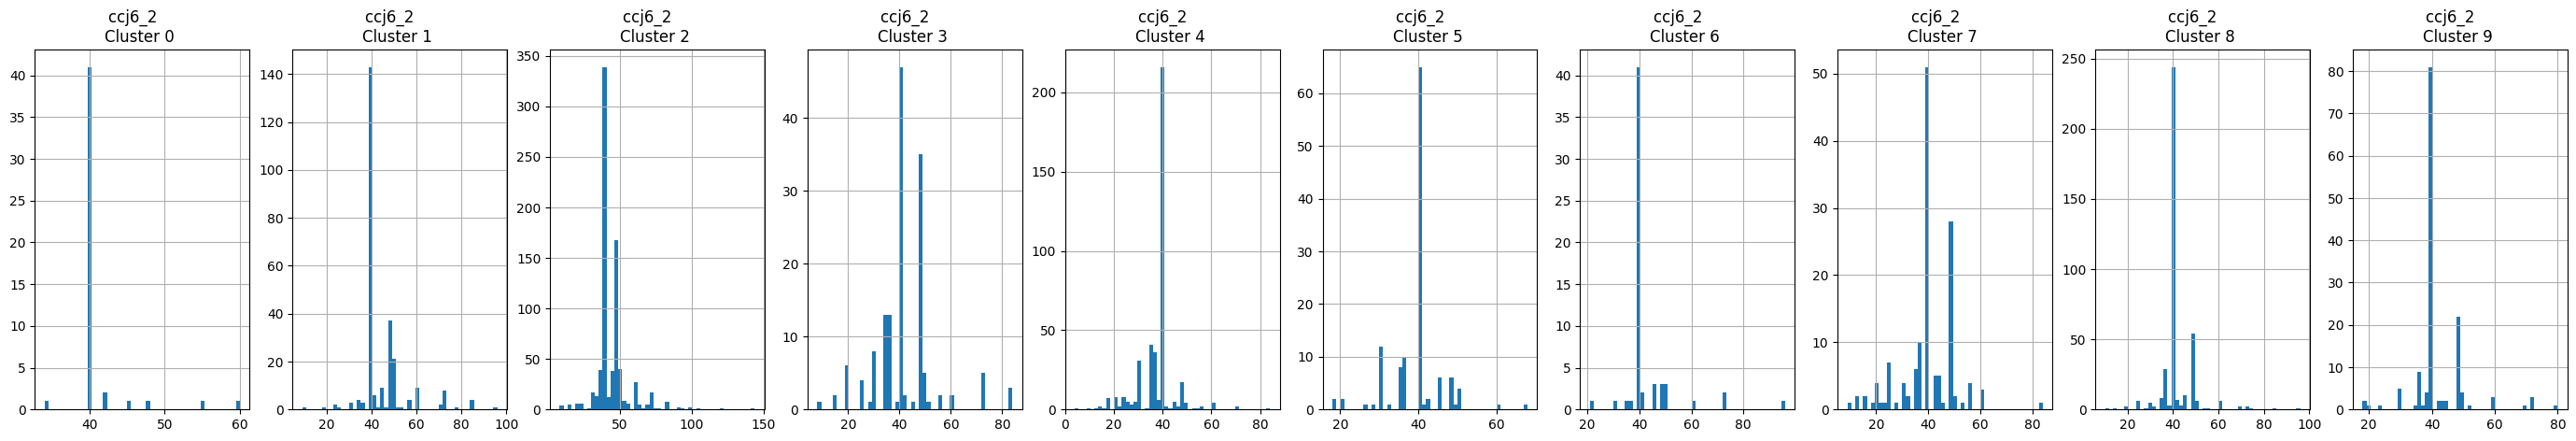

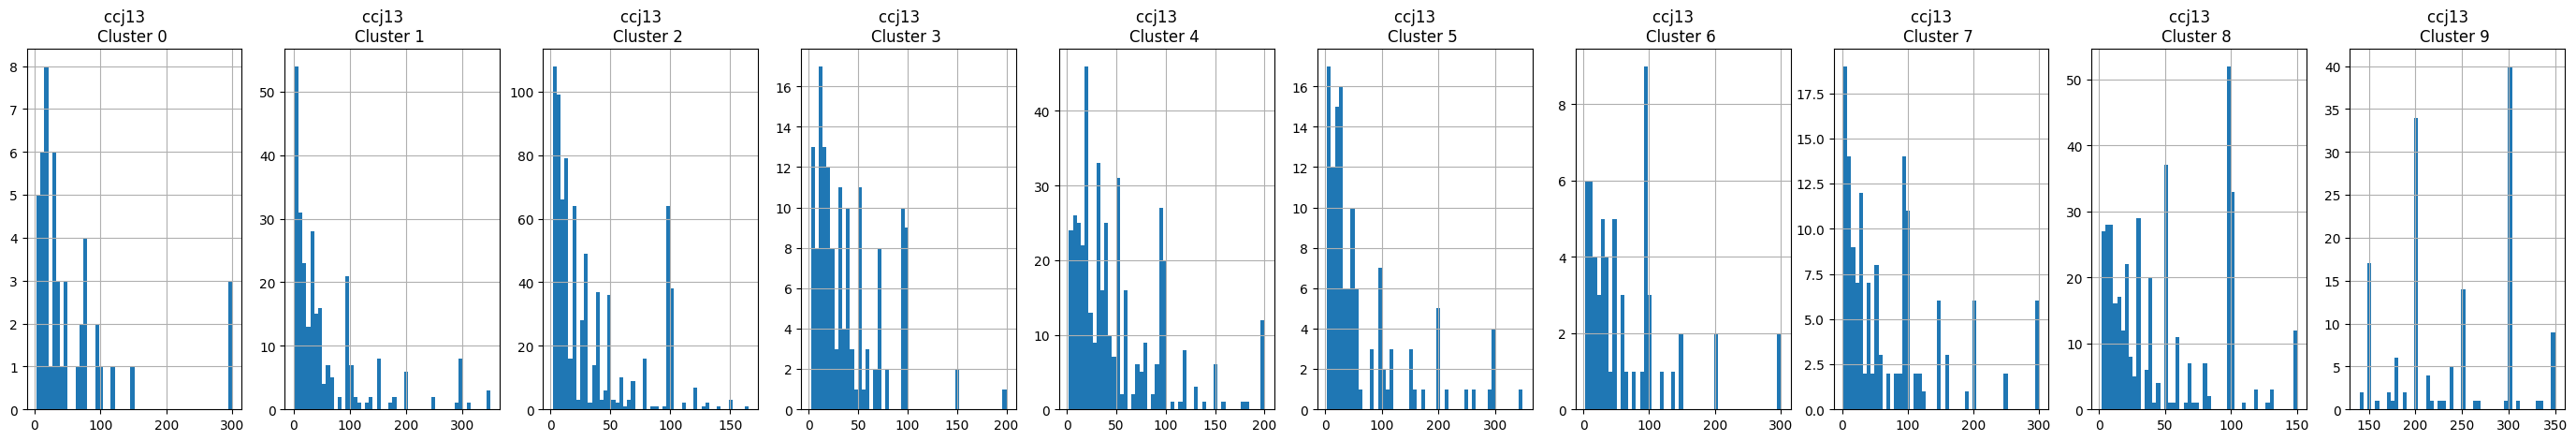

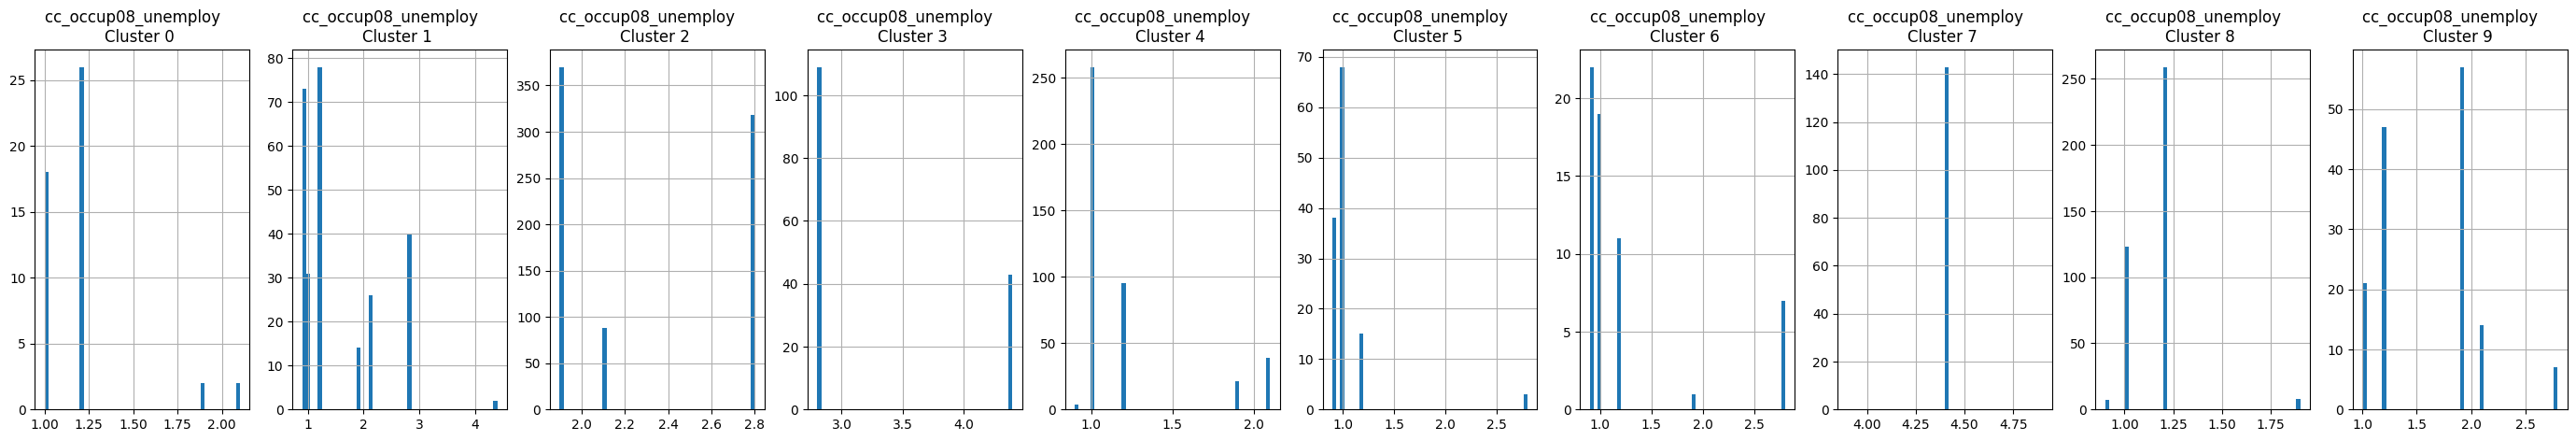

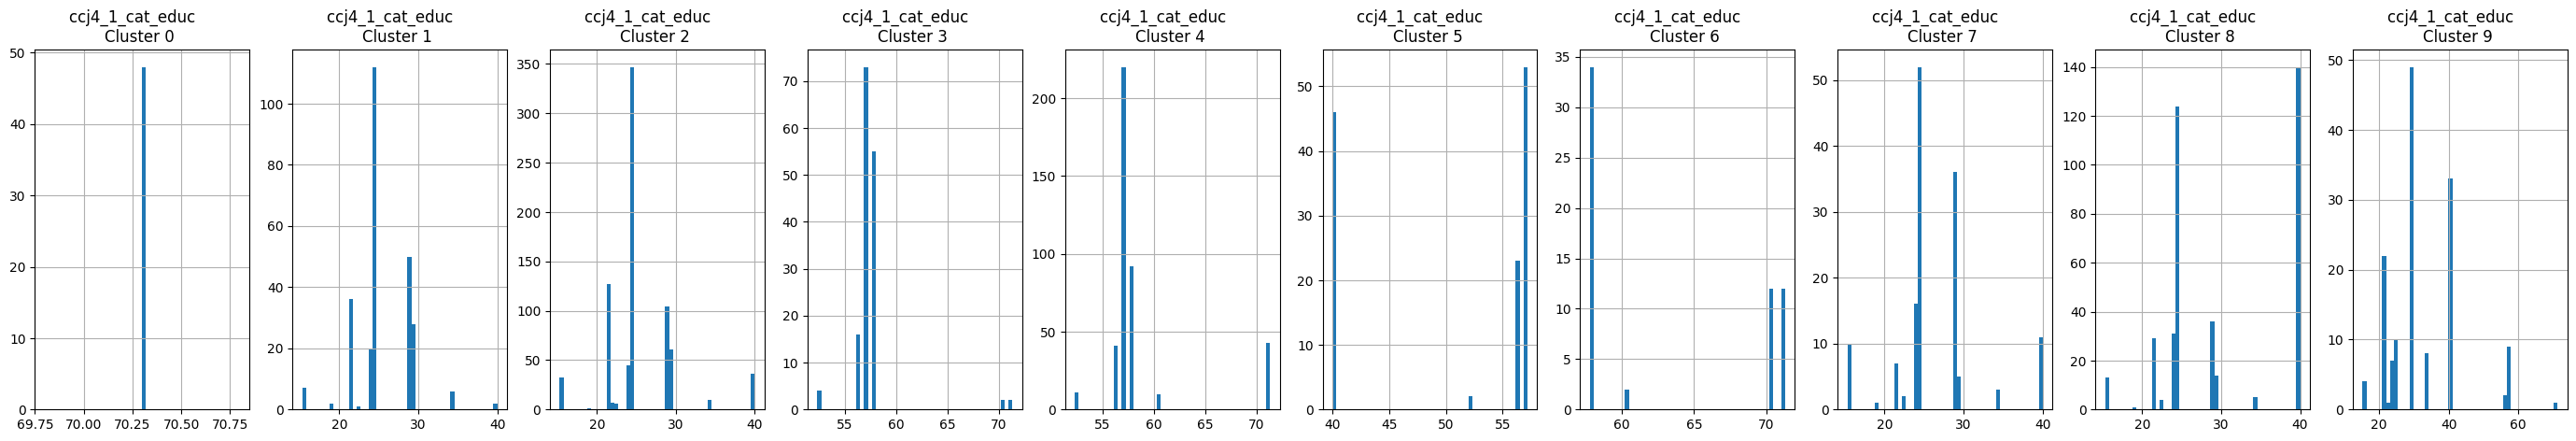

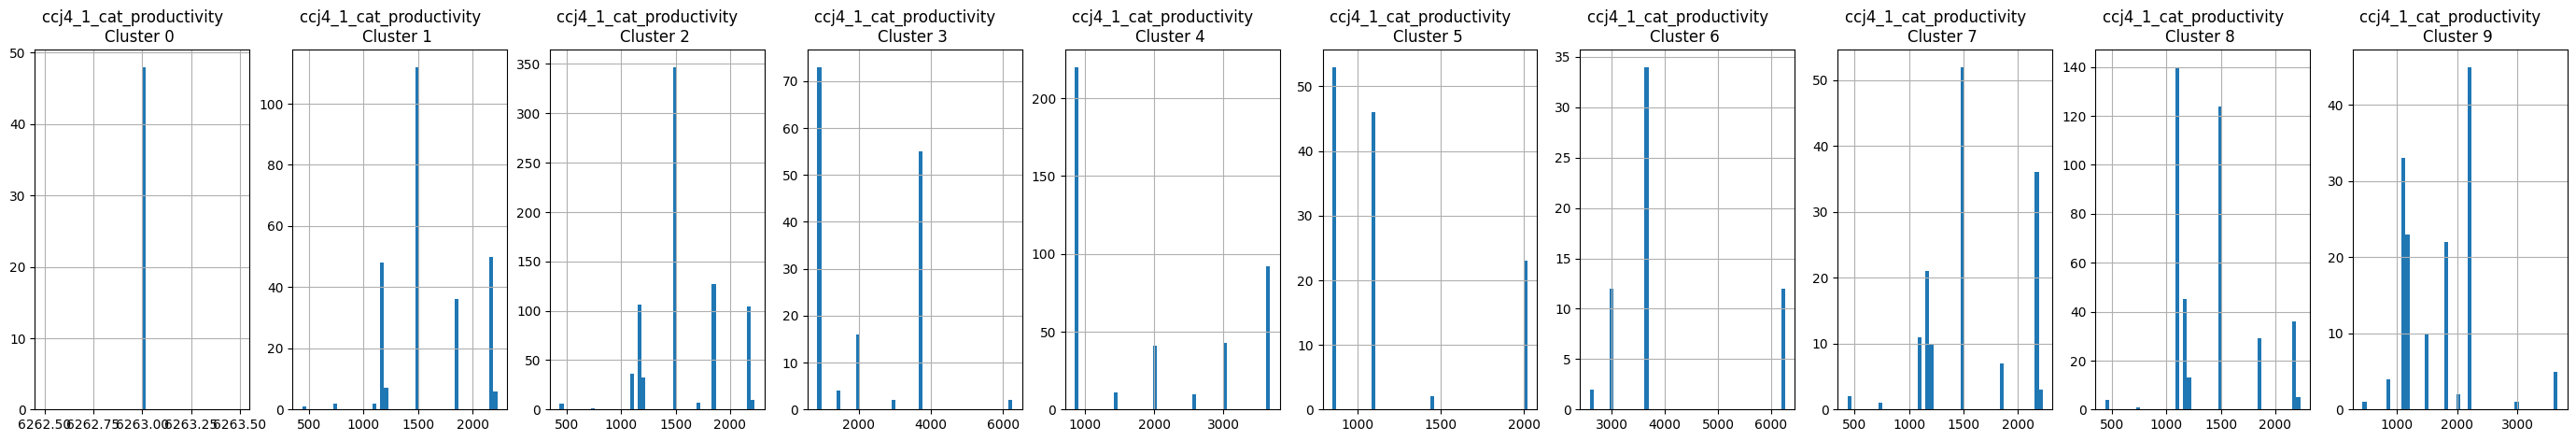

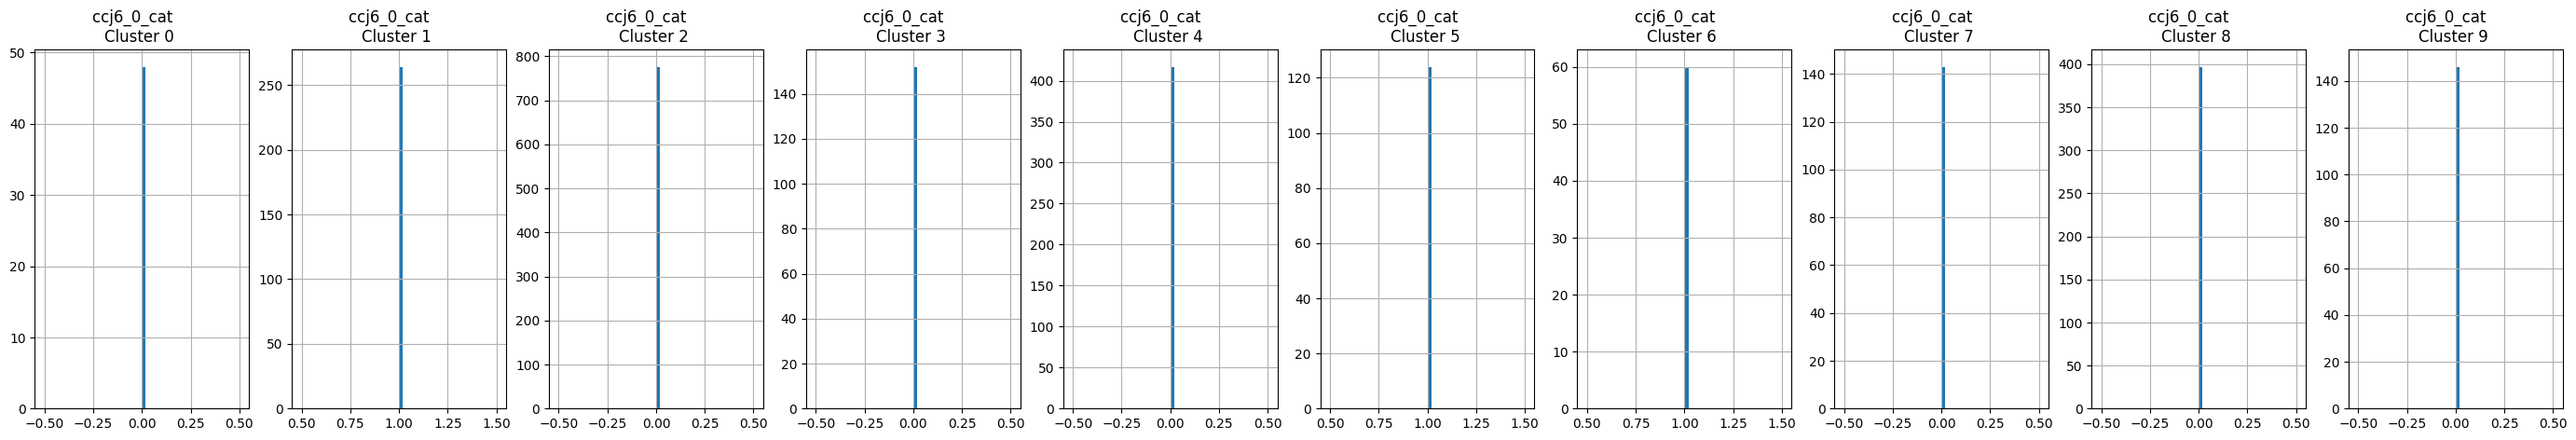

In [ ]:
# Построим гистограммы различных кластеров
for i in df.columns[:6]:
  plt.figure(figsize = (35, 5))
  for j in range(10):
    plt.subplot(1,10,j+1)
    cluster = df_cluster[df_cluster['cluster'] == j]
    cluster[i].hist(bins = 50)
    plt.title('{}    \nCluster {} '.format(i,j))

  plt.show()

In [ ]:
# Выведим содержимое столбца cluster
df_cluster['cluster'].value_counts()

,count
cluster,
2,776
4,417
8,397
1,264
3,152
9,146
7,143
5,124
6,60


Видим, что каждый кластер содержит достаточное количество наблюдей, нет совсем малочисленных кластеров. С помощью cluster_centers и гистограмм выше попробуем содержательно проинтерпретировать каждый из 10 кластеров:

 -`cluster 0 — Специалисты из высокообразованных отраслей со средней производительностью`  — продолжительность рабочей недели 40 часов, количество работников в компании 50–100 человек, низкий уровень безработицы (1.0), высокая доля работников с высшим образованием (70%), средняя производительность труда (1500), все респонденты не имеют подчинённых.

 -`cluster 1 — Руководители из отраслей с низкой долей высшего образования`  — продолжительность рабочей недели 40 часов, количество работников в компании около 100 человек, низкий уровень безработицы (1.0), низкая доля работников с высшим образованием (30%), низкая производительность труда (1000), все респонденты имеют подчинённых.

 -`cluster 2 — Специалисты из высокообразованных отраслей с низкой производительностью`  — продолжительность рабочей недели 40 часов, количество работников в компании около 50 человек, низкий уровень безработицы (1.0), высокая доля работников с высшим образованием (70%), низкая производительность труда (1000), все респонденты не имеют подчинённых.

 -`cluster 3 — Руководители из высокообразованных отраслей с высокой производительностью`  — продолжительность рабочей недели 40 часов, количество работников в компании 50–100 человек, низкий уровень безработицы (1.0), высокая доля работников с высшим образованием (70%), высокая производительность труда (2000–5000), все респонденты имеют подчинённых.

 -`cluster 4 — Рядовые работники средних компаний из отраслей с низкой долей высшего образования`  — продолжительность рабочей недели 40 часов, количество работников в компании 100–150 человек, низкий уровень безработицы (1.0), низкая доля работников с высшим образованием (30%), низкая производительность труда (1000), все респонденты не имеют подчинённых.

 -`cluster 5 — Руководители из отраслей со средней долей высшего образования и средней производительностью`  — продолжительность рабочей недели 40 часов, количество работников в компании около 100 человек, низкий уровень безработицы (1.0), средняя доля работников с высшим образованием (40%), средняя производительность труда (2500), все респонденты имеют подчинённых.

 -`cluster 6 — Рядовые работники небольших компаний из отраслей с низкой долей высшего образования и высокой производительностью`  — продолжительность рабочей недели 40 часов, количество работников в компании около 50 человек, низкий уровень безработицы (1.0), низкая доля работников с высшим образованием (30%), высокая производительность труда (4000), все респонденты не имеют подчинённых.

 -`cluster 7 — Рядовые работники крупных компаний из отраслей с низкой долей высшего образования и средней производительностью`  — продолжительность рабочей недели 40 часов, количество работников в компании около 150 человек, низкий уровень безработицы (1.0), низкая доля работников с высшим образованием (30%), средняя производительность труда (2000), все респонденты не имеют подчинённых.

 -`cluster 8 — Рядовые работники компаний среднего размера из отраслей со средней долей высшего образования и низкой производительностью`  — продолжительность рабочей недели 40 часов, количество работников в компании 50–100 человек, низкий уровень безработицы (1.0), средняя доля работников с высшим образованием (40%), низкая производительность труда (1000), все респонденты не имеют подчинённых.

 -`cluster 9 — Рядовые работники крупных компаний из отраслей с низкой долей высшего образования и низкой/средней производительностью` — продолжительность рабочей недели 40 часов, количество работников в компании 200–300 человек, низкий уровень безработицы (1.0), низкая доля работников с высшим образованием (30%), низкая/средняя производительность труда (1500), все респонденты не имеют подчинённых.

 Видим что данные легко поддаются интерпритации.

In [ ]:
df_final = df_f[['ccj10', 'ccj10_cat']].copy()
df_final['cluster'] = labels
df_final.head()

,ccj10,ccj10_cat,cluster
9,"45,000.00",0,4
16,"130,000.00",0,4
20,"20,000.00",1,2
24,"35,000.00",0,7
31,"22,000.00",1,8


In [ ]:
# Подсчитаем количество людей, долю людей с зп менее 30 тыс. руб. по кластерам
df_final.pivot_table(index=['cluster'], values='ccj10_cat', aggfunc=('mean', 'count'))

,count,mean
cluster,,
0,48,0.23
1,264,0.18
2,776,0.38
3,152,0.74
4,417,0.42
5,124,0.27
6,60,0.15
7,143,0.54
8,397,0.33


Выделенные кластеры, сформированные по характеристикам занятости и отраслевого контекста, характеризуются существенно разным уровнем низких зарплат.

#### **Метод главных компонент (PCA)**

PCA - это стандартный метод визуализации многомерных данных и их предварительной обработки. PCA уменьшает размерность (количество переменных) набора данных, пытаясь сохранить исходную информацию (дисперсию).

In [ ]:
# 1. Обучаем PCA на стандартизированных данных
# n_components=3, потому что строим двумерный scatterplot
pca = PCA(n_components=3, random_state=random_state)
principal_comp = pca.fit_transform(scaled_df)

# 2. Создаём DataFrame с главными компонентами
pca_df = pd.DataFrame(data=principal_comp, columns=['pca1', 'pca2', 'pca3'])

# 3. Присоединяем метки кластеров
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster': labels})], axis=1)

# 4. Смотрим, сколько дисперсии объясняют компоненты
print("Доля объяснённой дисперсии:", pca.explained_variance_ratio_)
print("Суммарно:", pca.explained_variance_ratio_.sum())

Доля объяснённой дисперсии: [0.4125257  0.25619974 0.15342332]
Суммарно: 0.8221487677882483


In [ ]:
# 5. Посмотрим, какие исходные признаки дают наибольший вклад
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=df.columns
)
print(loadings.sort_values(by='PC1', ascending=False))

                          PC1   PC2   PC3
ccj6_0_cat               0.92 -0.29  0.24
ccj4_1_cat_educ          0.12  0.81  0.46
ccj4_1_cat_productivity  0.04  0.25  0.26
ccj13                    0.03  0.04 -0.17
ccj6_2                   0.00 -0.05 -0.00
cc_occup08_unemploy     -0.36 -0.45  0.80


PC1 в основном определяется наличием руководящей функции / подчинённых

PC2 в основном - образовательной структурой и производительностью отрасли

PC3 - в основном безработицей по профессиональной группе.

То есть PCA показывает, что пространство  признаков действительно имеет несколько относительно самостоятельных направлений вариации.

In [ ]:
# Добавим к главным компонентам метки кластеров
pca_df = pd.DataFrame(data = principal_comp[:,:2], columns =['pca1','pca2'])
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster':labels})], axis = 1)
pca_df.head()

,pca1,pca2,cluster
0,-0.05,0.42,4
1,-0.04,0.41,4
2,-0.26,-0.05,2
3,-0.45,-0.46,7
4,-0.16,0.06,8


In [ ]:
pca_df.shape

(2527, 3)

In [ ]:
pca_df['cluster'].value_counts()

,count
cluster,
2,776
4,417
8,397
1,264
3,152
9,146
7,143
5,124
6,60


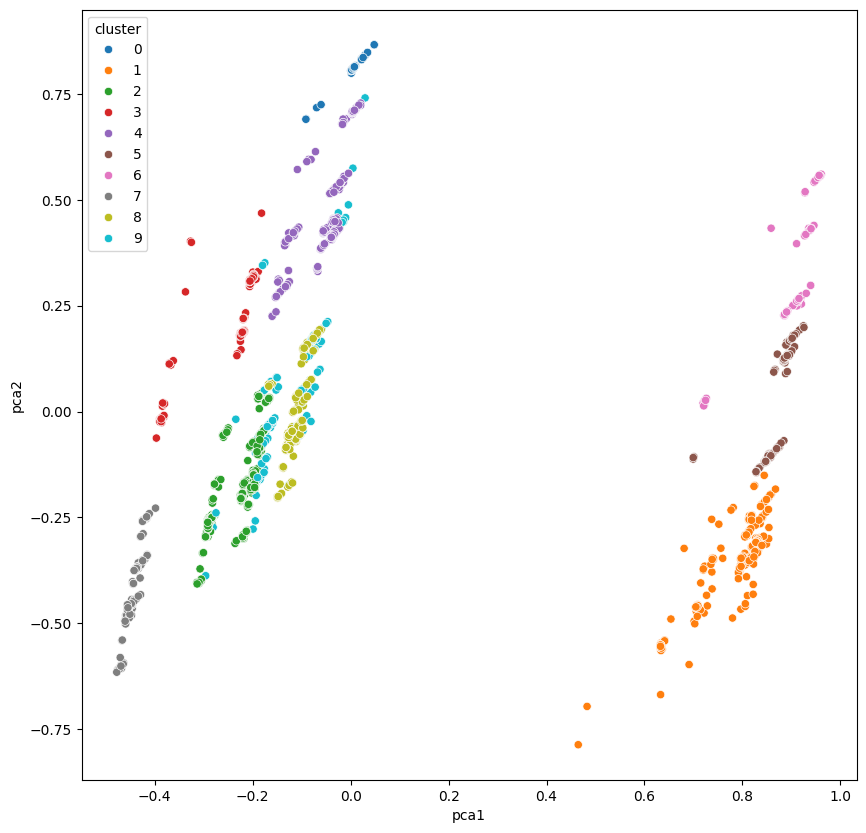

In [ ]:
# Построим двумерный scatter plot на главных компонентах по кластерам
plt.figure(figsize=(10,10))
ax = sns.scatterplot(x="pca1", y="pca2", hue = "cluster", data = pca_df, palette='tab10')
plt.show()